# DESeq2 with new reference genome
but with pre-filtering! 
# Phase 2 vs. Phase 2

focusing on pairwise comparisons of oysters that experienced both phase 1 and phase 2

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(EnhancedVolcano) # for volcano plots
library(vegan) # for permanova
library(pheatmap)
library(RColorBrewer)
library(limma) # for removing batch effects

## 1. read counts matrix and meta data

### counts matrix
the counts matrix was generated in [processing_seqs.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/processing/nov25_refSeq/processing_seqs.ipynb) with the new reference genome ([NCBI GCF_053477285.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)), indexed and aligned with `hisat2`, and counts matrix generated with `featureCounts` (all with the same flags/settings that were used with the old genome)

In [3]:
# counts matrix
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')

# set gene_ID as row name
rownames(counts) <- counts$Gene_ID

# remove gene id and length
counts.df <- counts %>%
select(-Gene_ID, -Length)

head(counts.df)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [4]:
# number of genes with 0 counts for all samples
sum(rowSums(counts.df) == 0) # 4884 genes

# pre-filter those rows
counts.filtered <- counts.df[!rowSums(counts.df) == 0,]

# double check this worked
dim(counts.df) # 33903 total genes
dim(counts.filtered) # 29019 genes with at least 1 read

[1] 4884

[1] 33903   120

[1] 29019   120

### meta data
the meta data csv was already generated in [deseq_p1.v.p1](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/deseq_p1.v.p1.ipynb), so just reading in here

In [5]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(!grepl("Nu", Sample)) # filter out phase 1 samples - only want phase 2

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

head(meta)
dim(meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3


[1] 96  8

creating new column for 'complete' treatment - so I can easily compare phase 1 to phase 2

In [6]:
meta$complete_trtmt <- paste(meta$Phase1_treatment, meta$Phase2_treatment)

# check
head(meta,2)
tail(meta,2)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm


,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
W6_W3_G36,warm,warm,normoxic,6,warm,warm,normoxic,3,warm warm
W6_W4_G48,warm,warm,normoxic,6,warm,warm,normoxic,4,warm warm


In [7]:
# setting the same order for counts matrix and meta data
counts.filtered <- counts.filtered[,rownames(meta)]
all(rownames(meta) == colnames(counts.filtered))

[1] TRUE

## 2. DESeq2
analyzing differential gene expression with [`DESeq2`](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)

#### contrasts
setting up contrasts (telling DESeq what is the control treatment)

In [8]:
# tempature treatments
meta$Phase1_temp <- factor(meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

meta$Phase2_temp <- factor(meta$Phase2_temp,
                                   levels = c('ambient', 'warm'))

In [9]:
# DO treatments
meta$Phase1_DO <- factor(meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

meta$Phase2_DO <- factor(meta$Phase2_DO,
                                   levels = c('normoxic', 'hypoxic'))

### complete treatments
starting simple with looking at phase 1 treatments (not splitting into temperature/DO, just looking at combination of treatments)

In [10]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = counts.filtered,
                              colData = meta,
                              design = ~ complete_trtmt)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



class: DESeqDataSet 
dim: 29019 96 
metadata(1): version
assays(1): counts
rownames(29019): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



[1] "Intercept"                                  
 [2] "complete_trtmt_both.control_vs_both.both"   
 [3] "complete_trtmt_both.hypoxic_vs_both.both"   
 [4] "complete_trtmt_both.warm_vs_both.both"      
 [5] "complete_trtmt_control.both_vs_both.both"   
 [6] "complete_trtmt_control.control_vs_both.both"
 [7] "complete_trtmt_control.hypoxic_vs_both.both"
 [8] "complete_trtmt_control.warm_vs_both.both"   
 [9] "complete_trtmt_hypoxic.both_vs_both.both"   
[10] "complete_trtmt_hypoxic.control_vs_both.both"
[11] "complete_trtmt_hypoxic.hypoxic_vs_both.both"
[12] "complete_trtmt_hypoxic.warm_vs_both.both"   
[13] "complete_trtmt_warm.both_vs_both.both"      
[14] "complete_trtmt_warm.control_vs_both.both"   
[15] "complete_trtmt_warm.hypoxic_vs_both.both"   
[16] "complete_trtmt_warm.warm_vs_both.both"

looks like there were 29019 genes pre-filter

for the filter, I want to make sure to filter out rows with just one strong signal from one sample (for example, I sometimes see a DEG but at closer look, it is driven by high expression of one sample) 

to do this, i'm going to only keep genes that have a consistent signal (at least 5 reads) in at least 5 samples in at least one treatment treatment combo 

### pre-filter genes 

In [11]:
# filter genes with inconsistent/low reads 
dds$group <- factor(dds$complete_trtmt)

keep <- apply(counts(dds), # raw counts matrix
              1, # apply across rows - for each row/gene, apply this function: 
              function(x) {
  any(tapply(x, dds$group, # split counts for this gene by treatment combo
             function(g) sum(g >= 5) >= 3)) # does this treatment combo have at least 3 samples with counts of 5 or more?
             # any = is at least one group true?
})
dds_filtered <- dds[keep, ]


In [12]:
dds_filtered

class: DESeqDataSet 
dim: 26060 96 
metadata(1): version
assays(4): counts mu H cooks
rownames(26060): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(78): baseMean baseVar ... deviance maxCooks
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

21,663 genes after filtering

In [13]:
26060 / 29019
# so maintaining about 90% of genes

[1] 0.8980323

Checking how strict this filtering was by looking at the control oysters and see how many genes have reasonable counts (not outliers/no counts) 

#### run DESeq again

In [14]:
# run DESeq on the filtered dds object
dds_filtered <- DESeq(dds_filtered)

# run vst on new dds object
vst_mat <- assay(vst(dds_filtered, blind = FALSE))

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [15]:
dim(vst_mat)
head(vst_mat)

[1] 26060    96

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.506739,11.290426,11.274519,11.128664,10.825870,10.807494,11.229752,10.895370,11.007769,11.031302,⋯,11.733793,10.445095,10.946084,11.422612,11.278501,11.089837,11.234382,11.073554,11.706315,11.542363
LOC144621269,8.493607,11.007891,11.445643,10.336375,11.486465,10.494344,12.769196,10.901695,8.233225,8.059534,⋯,13.887492,7.979161,8.067537,10.000519,8.416978,8.785045,13.435455,8.209287,9.643918,13.412882
LOC111120925,8.579916,8.266198,9.701748,8.103600,8.205353,8.079663,7.804871,7.902852,7.804871,7.901232,⋯,9.557409,7.804871,7.990732,9.721694,8.635261,8.328068,8.036248,7.906286,8.137336,8.103365
LOC144621283,9.862385,10.313096,10.337655,10.153495,10.252870,10.549224,10.513537,9.713574,10.077554,10.183225,⋯,9.960665,10.461483,10.193975,10.339949,10.309120,10.220672,9.935887,10.840620,9.951071,9.983954
LOC144621276,13.437845,13.481503,13.655653,13.487925,13.768186,13.890567,13.703314,13.202264,13.746433,13.420767,⋯,14.016282,13.293335,13.840370,13.533890,13.078933,13.265197,13.925498,13.359720,13.406014,13.356125
LOC111115920,8.990057,9.064179,8.956104,8.786534,8.700691,8.644403,8.545452,9.574368,8.749270,9.428388,⋯,8.666097,8.765803,9.260882,8.896594,9.604774,9.607869,9.066350,9.239288,8.726199,8.846351


### explore results and fit

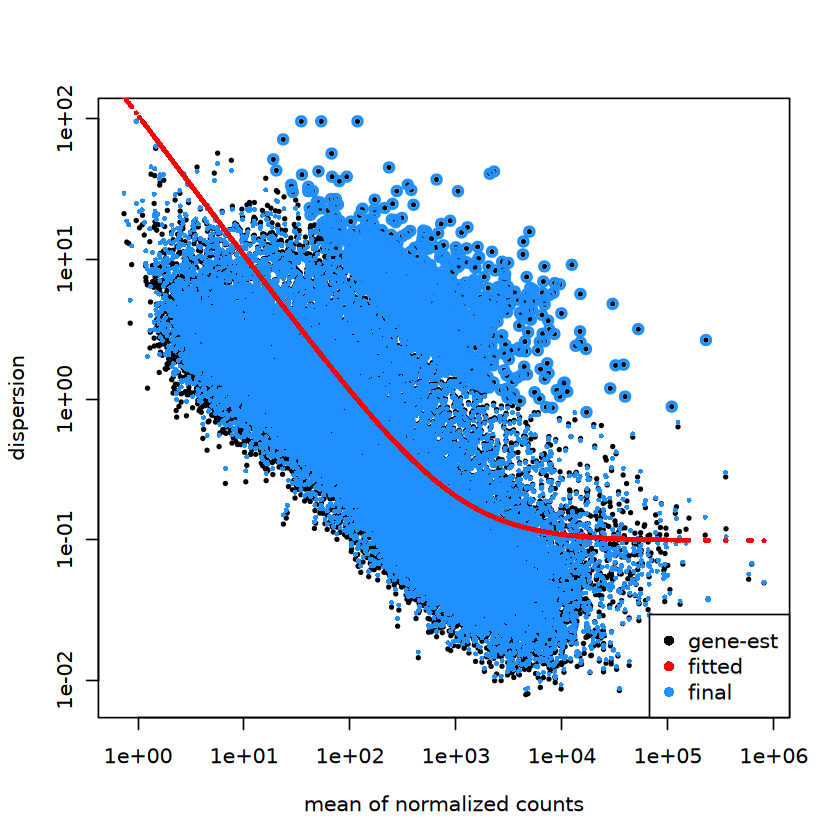

In [16]:
plotDispEsts(dds_filtered)

### nMDS
normalize and transform DESeq object using csv (variance stabilized expression matrix)

In [17]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,81.17469,84.48860,79.08079,83.95106,82.34655,91.47219,83.49670,83.45295,74.71603,⋯,99.31810,80.23296,70.37641,74.44621,71.35128,74.81232,95.29262,77.84672,76.12725,100.05484
B1_W5_O50,81.17469,0.00000,78.26415,68.56732,64.77855,70.46682,71.67051,82.23779,79.05891,78.36182,⋯,82.11093,86.24772,79.85927,79.98522,82.40868,79.59138,83.94963,81.38642,76.19416,80.50329
B2_B5_O51,84.48860,78.26415,0.00000,86.15990,80.53545,85.46521,82.04571,92.73349,95.80407,92.31772,⋯,87.72215,98.29659,89.80196,77.86505,88.77273,90.94060,88.38233,91.18474,87.02460,83.53047
B2_C4_O40,79.08079,68.56732,86.15990,0.00000,72.32386,70.51130,79.86594,80.24003,82.88784,73.22532,⋯,88.09038,81.39254,77.52661,77.49506,78.39671,76.59543,91.35576,75.68057,60.96719,88.57371
B3_B4_O41,83.95106,64.77855,80.53545,72.32386,0.00000,75.43176,77.50838,87.30230,75.78435,82.20989,⋯,80.15785,89.93878,80.93280,83.62561,87.47606,84.28828,79.88400,84.55540,79.55804,80.52718
B3_C3_O30,82.34655,70.46682,85.46521,70.51130,75.43176,0.00000,82.48342,86.02701,86.42159,81.41093,⋯,91.50152,87.99027,74.19626,83.74453,84.78347,81.06781,94.37442,78.25852,78.76372,92.71638


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,11.491594,12.639810,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-2.333362,-16.608593,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-17.071450,-7.883250,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,6.223148,-7.419990,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-7.832214,-16.339906,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,6.504263,-5.832943,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


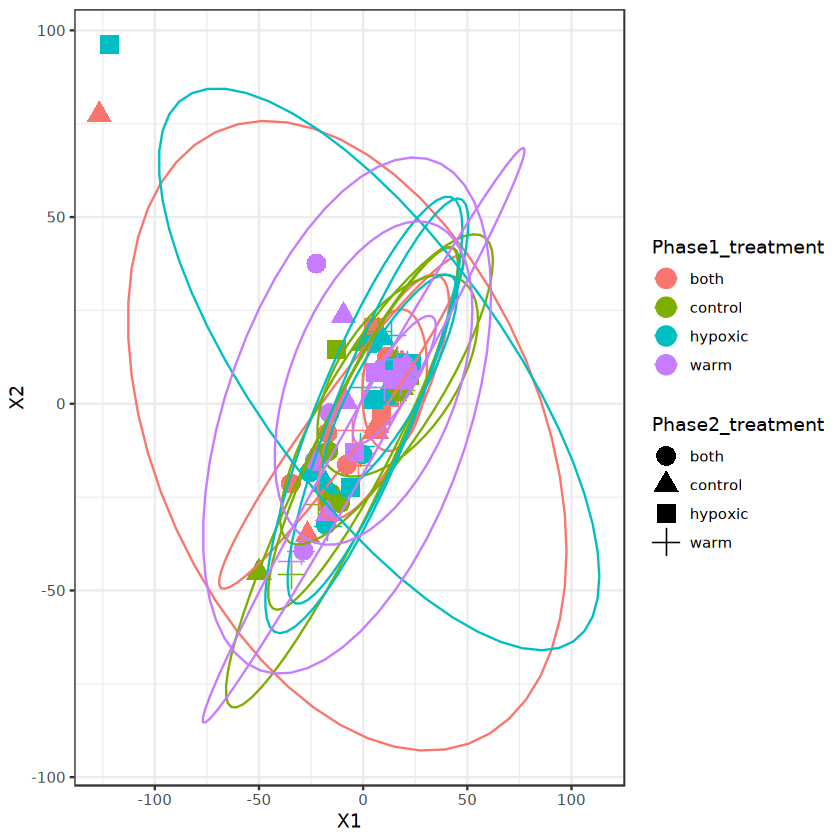

In [18]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

nmds.plot

In [19]:
sample_dists <- dist(t(assay(vsd)))  # transpose so samples are rows
head(sample_dists)

meta <- as.data.frame(colData(vsd))
head(meta)

[1] 81.17469 84.48860 79.08079 83.95106 82.34655 91.47219

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [20]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3236.924,0.008307427,0.7930077,0.776
Phase1_DO,1,3376.258,0.008665020,0.8271427,0.720
Phase2_temp,1,8814.911,0.022623088,2.1595475,0.002
Phase2_DO,1,5828.697,0.014959099,1.4279609,0.066
Phase1_temp:Phase1_DO,1,2739.712,0.007031354,0.6711967,0.956
Phase1_temp:Phase2_temp,1,2713.907,0.006965124,0.6648746,0.962
Phase1_DO:Phase2_temp,1,3698.967,0.009493240,0.9062026,0.591
Phase1_temp:Phase2_DO,1,3207.229,0.008231214,0.7857326,0.812
Phase1_DO:Phase2_DO,1,3594.704,0.009225652,0.8806593,0.640


- Phase2_temp has a significant effect on GE (P = 0.004) and explains ~2.2% of the variation in GE
- Phase2_DO also has a significant effect on GE (P = 0.040) and explains ~1.5% of the variance
- The interaction of Phase2_temp and Phase2_DO is significant (P = 0.050) and explains ~1.5% of the variation in GE
    - this means the effect of phase 2 temp depends on the value of phase 2 DO (or vice versa)
- The majoirty of the variation in GE is not explained by the treatments (R2 = 0.84)

### heatmap of sample-to-sample distances using the variance stabilizing transformed values
following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [21]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- dist(t(assay(dds_filtered)))
head(sample_dists)

[1]  559109.0  658789.3  525933.1  551766.8  502959.1 1120977.4

In [22]:
head(vsd)

class: DESeqTransform 
dim: 6 96 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

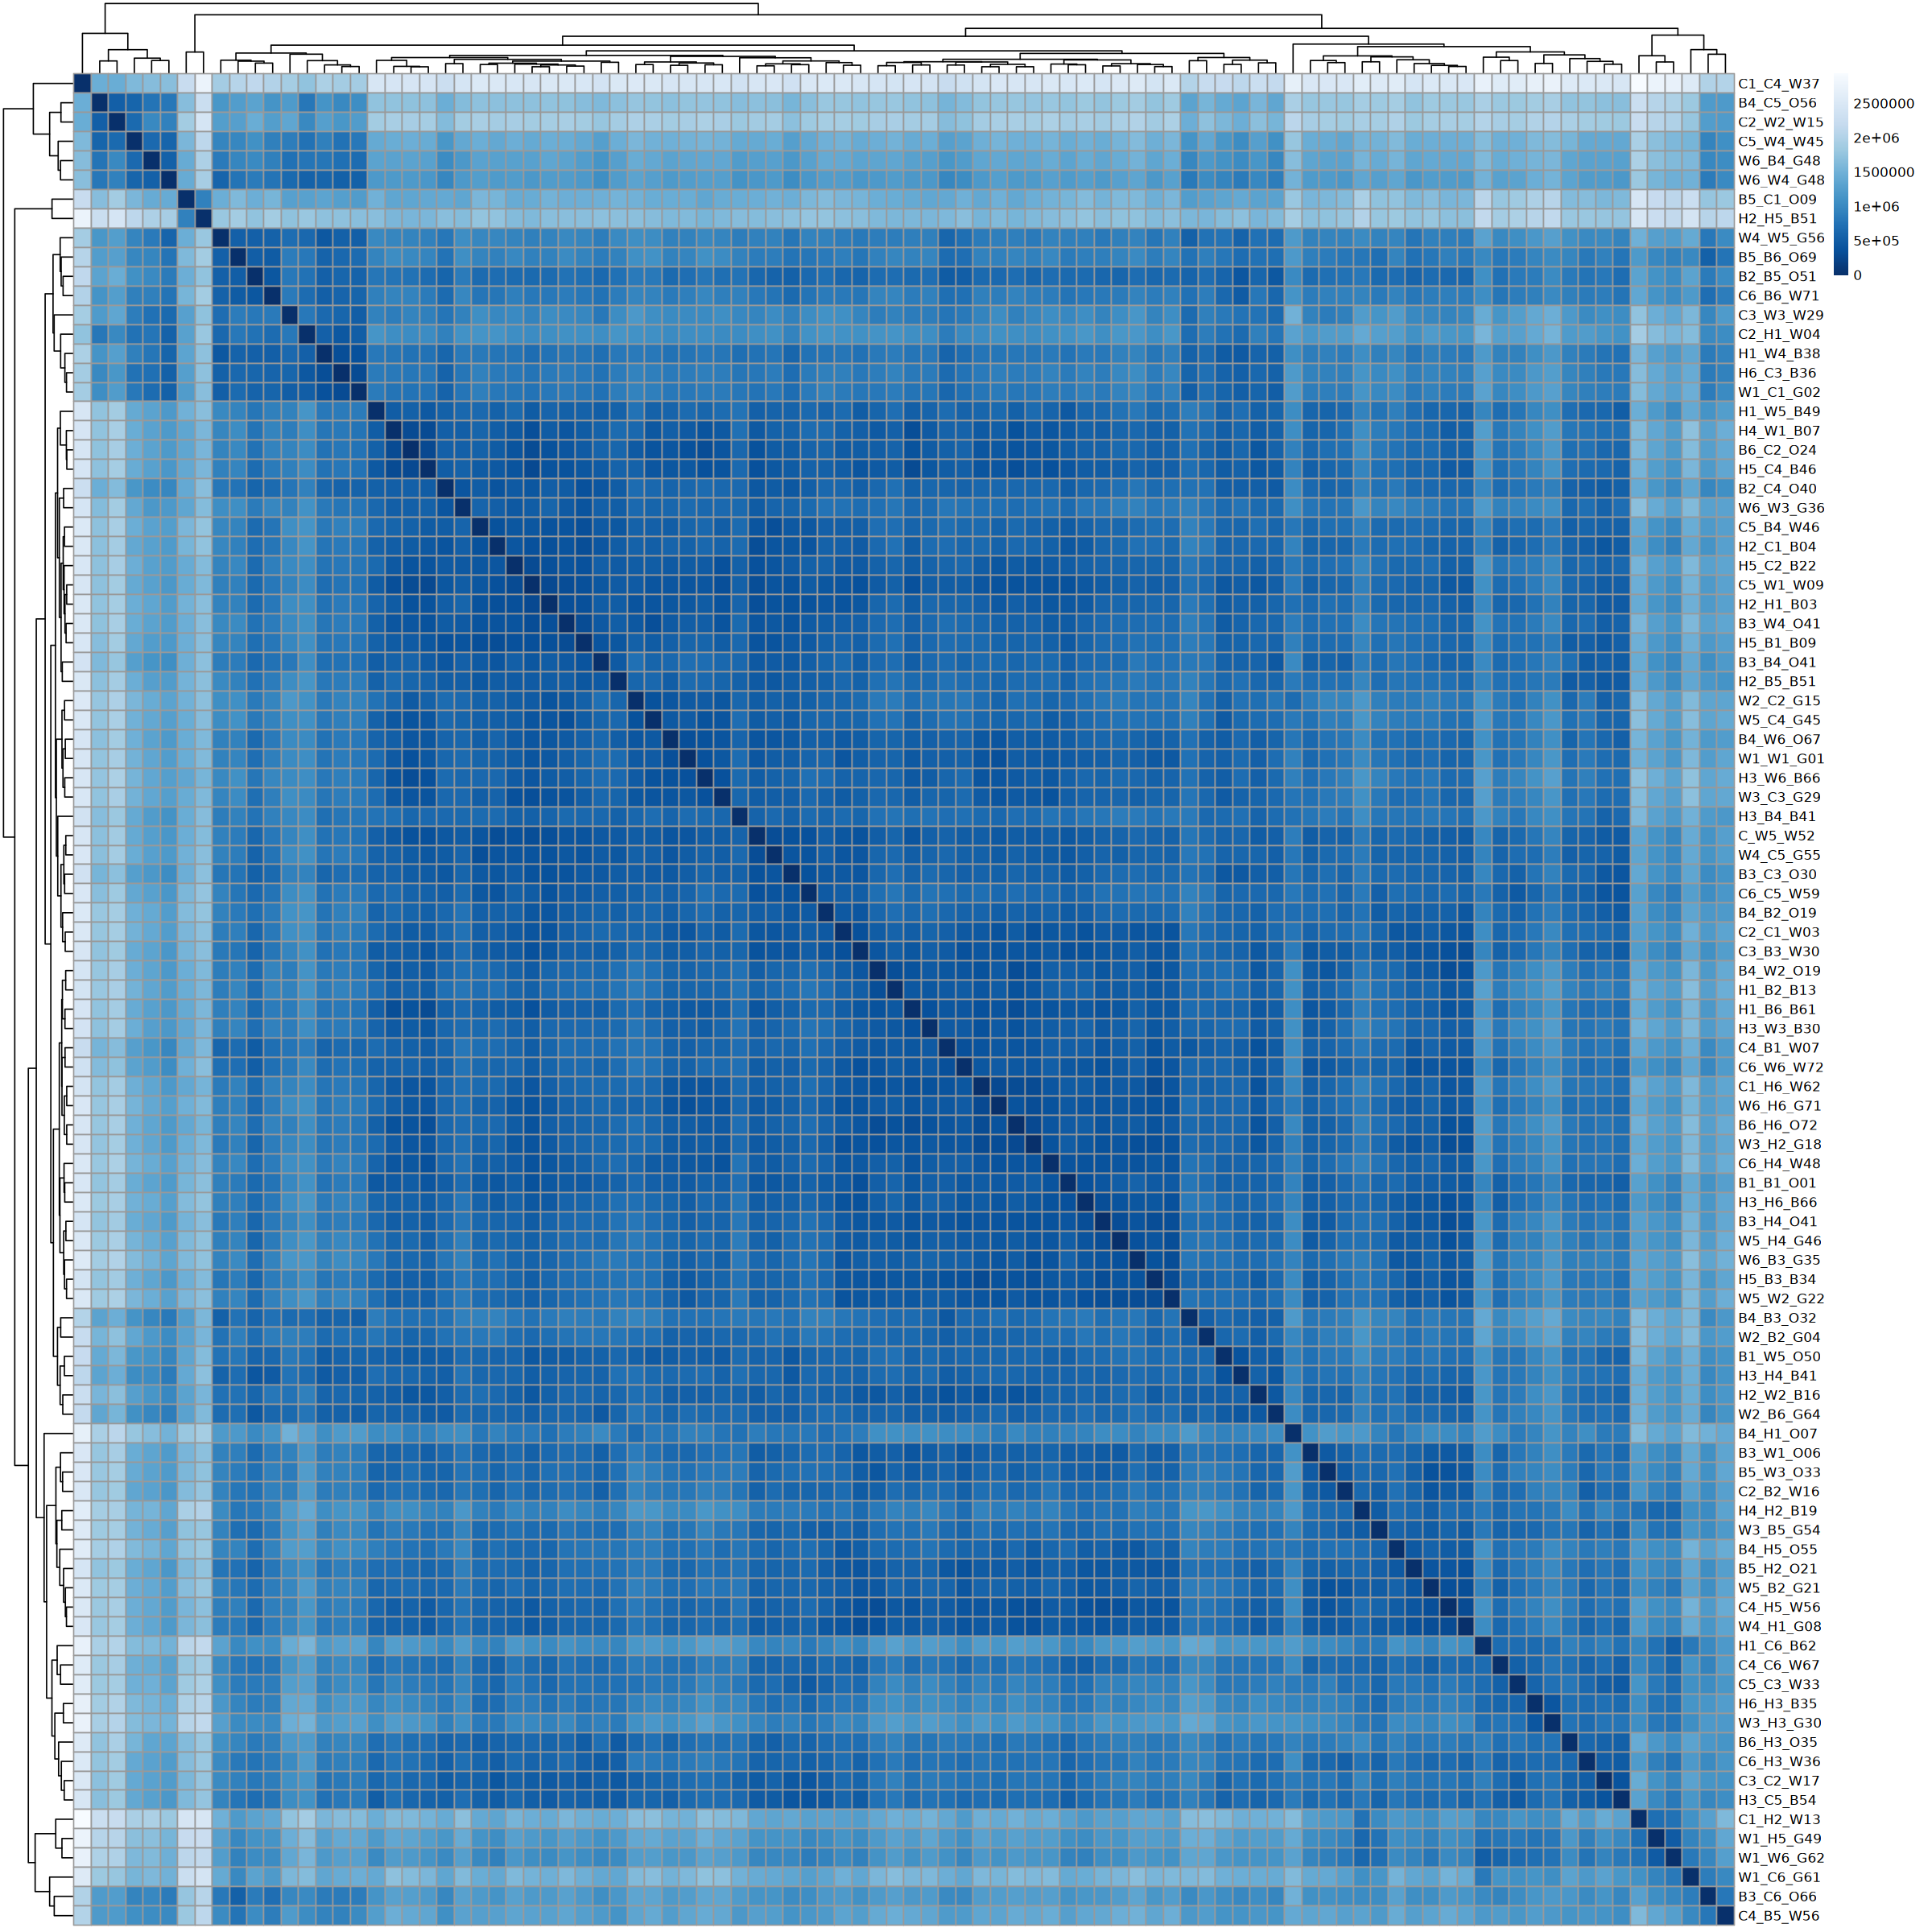

In [23]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

it's weird that there's two samples that are very dissimilar to every other sample, but appear closer together - (HH and BC) - if you look at the nMDS plots too, they look like outliers from their replicates so should consider removing those samples from analysis 

In [24]:
pcaData <- plotPCA(vsd, intgroup = c( "Phase1_treatment", "Phase2_treatment"), returnData = TRUE)
head(pcaData)

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-13.0437674,-3.611237,both:both,both,both,B1_B1_O01
B1_W5_O50,10.9126353,8.420179,both:warm,both,warm,B1_W5_O50
B2_B5_O51,15.6111253,-4.280954,both:both,both,both,B2_B5_O51
B2_C4_O40,1.7498153,5.145200,both:control,both,control,B2_C4_O40
B3_B4_O41,15.1470227,6.226355,both:both,both,both,B3_B4_O41
B3_C3_O30,0.4126957,5.078508,both:control,both,control,B3_C3_O30


### PCA

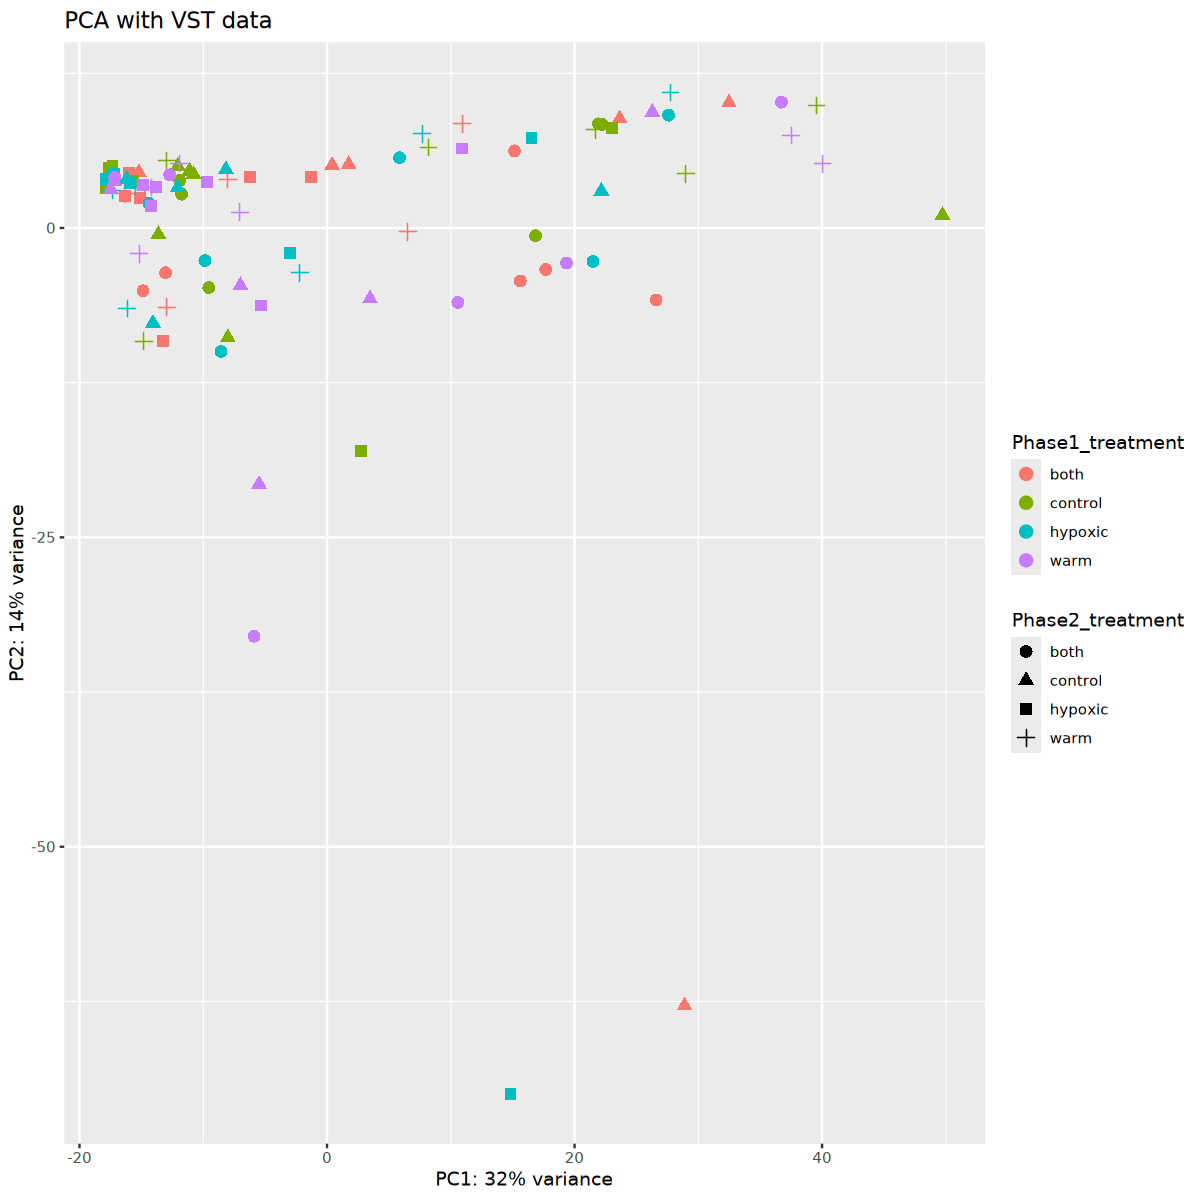

In [25]:
options(repr.plot.width=10, repr.plot.height=10)

percentVar <- round(100 * attr(pcaData, "percentVar"))

ggplot(pcaData, aes(x = PC1, y = PC2, color = Phase1_treatment, shape = Phase2_treatment)) +
  geom_point(size =3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  coord_fixed() +
  ggtitle("PCA with VST data")

there's those two samples again in the bottom of the plot - B5_C1_O09 and H2_H5_B51 - that cluster away from everything else 

what do things look like if I remove those?

In [26]:
# remove two samples
dds_rm<- dds_filtered[, !colnames(dds_filtered) %in% c("B5_C1_O09", "H2_H5_B51")]

In [27]:
# normalization & transformation
vsd_filtered <- vst(dds_rm)

# calculate sample distances
sample_dists_filtered <- dist(t(assay(vsd_filtered)))
head(sample_dists_filtered)

[1] 80.56880 83.86479 78.49837 83.33886 81.75433 90.81074

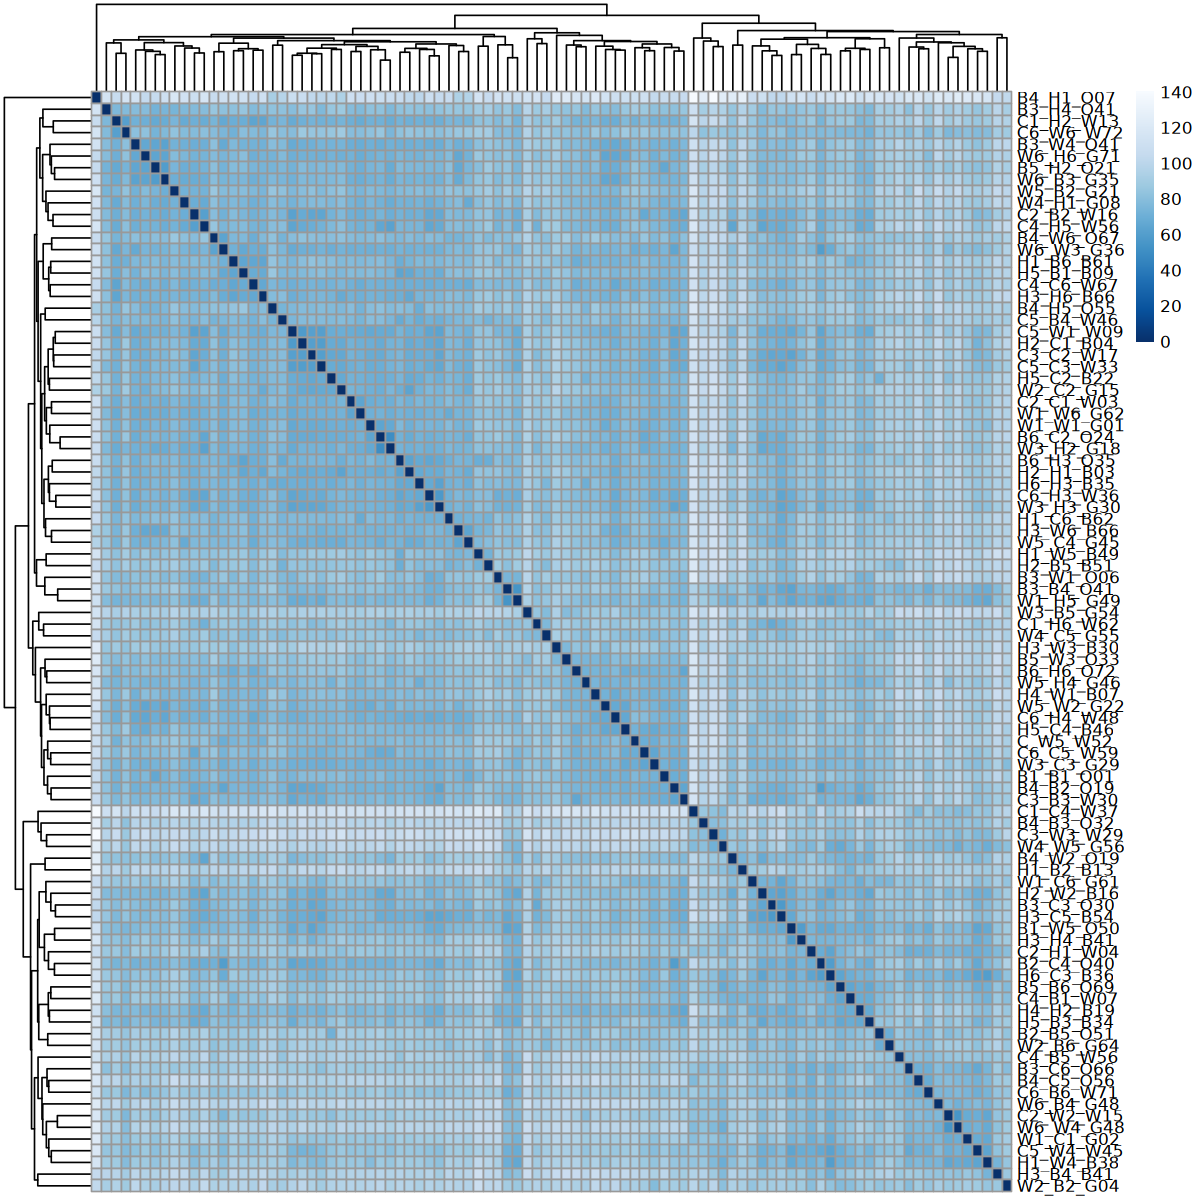

In [28]:
sampleDistMatrix <- as.matrix(sample_dists_filtered)
rownames(sampleDistMatrix) <- paste(colnames(vsd_filtered))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists_filtered,
         clustering_distance_cols = sample_dists_filtered,
         col = colors)

In [29]:
pcaData_filtered <- plotPCA(vsd_filtered, intgroup = c( "Phase1_treatment", "Phase2_treatment"), returnData = TRUE)
head(pcaData_filtered)

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-13.110647,-8.330373,both:both,both,both,B1_B1_O01
B1_W5_O50,12.421904,4.383282,both:warm,both,warm,B1_W5_O50
B2_B5_O51,15.652446,-13.012978,both:both,both,both,B2_B5_O51
B2_C4_O40,2.546170,7.187841,both:control,both,control,B2_C4_O40
B3_B4_O41,15.867706,6.575690,both:both,both,both,B3_B4_O41
B3_C3_O30,1.332008,5.057415,both:control,both,control,B3_C3_O30


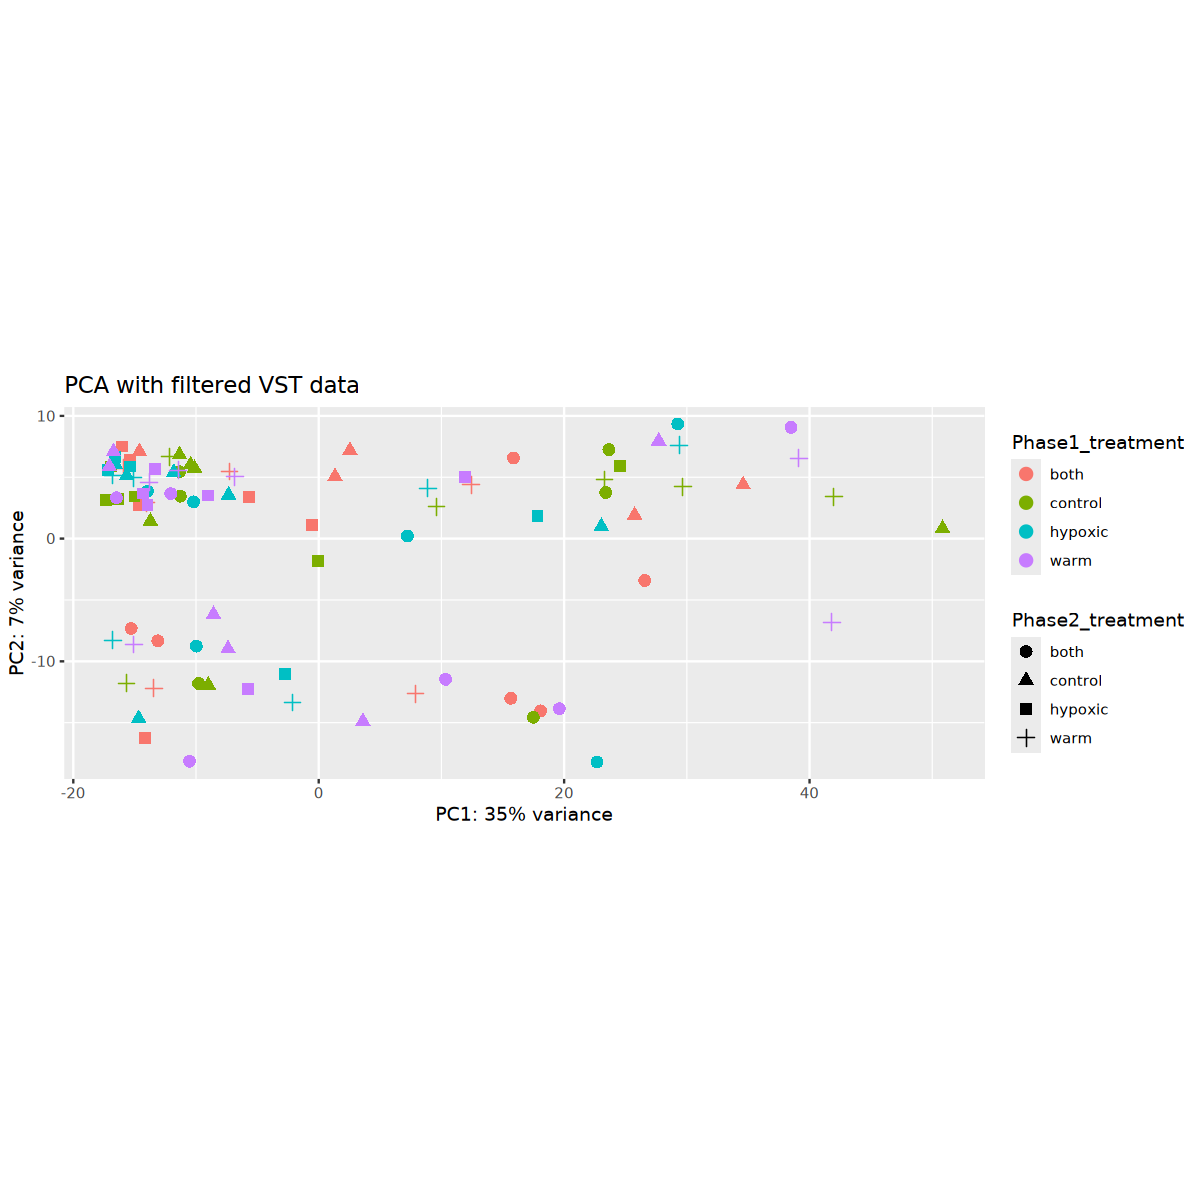

In [30]:
options(repr.plot.width=10, repr.plot.height=10)

percentVar <- round(100 * attr(pcaData_filtered, "percentVar"))

ggplot(pcaData_filtered, aes(x = PC1, y = PC2, color = Phase1_treatment, shape = Phase2_treatment)) +
  geom_point(size =3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  coord_fixed() +
  ggtitle("PCA with filtered VST data")

In [31]:
# calculate MDS value from distance matrix
mdsData_filtered <- data.frame(cmdscale(sample_dists_filtered))
mds_filtered <- cbind(mdsData_filtered, as.data.frame(colData(vsd_filtered))) # combine with sample data
head(mds_filtered)

,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,16.0046465,-8.792288998,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-13.6021237,6.083812880,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-18.8291291,-0.658455087,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-0.9679314,0.006604586,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-17.3399189,9.290500622,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,0.1441657,15.910793629,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


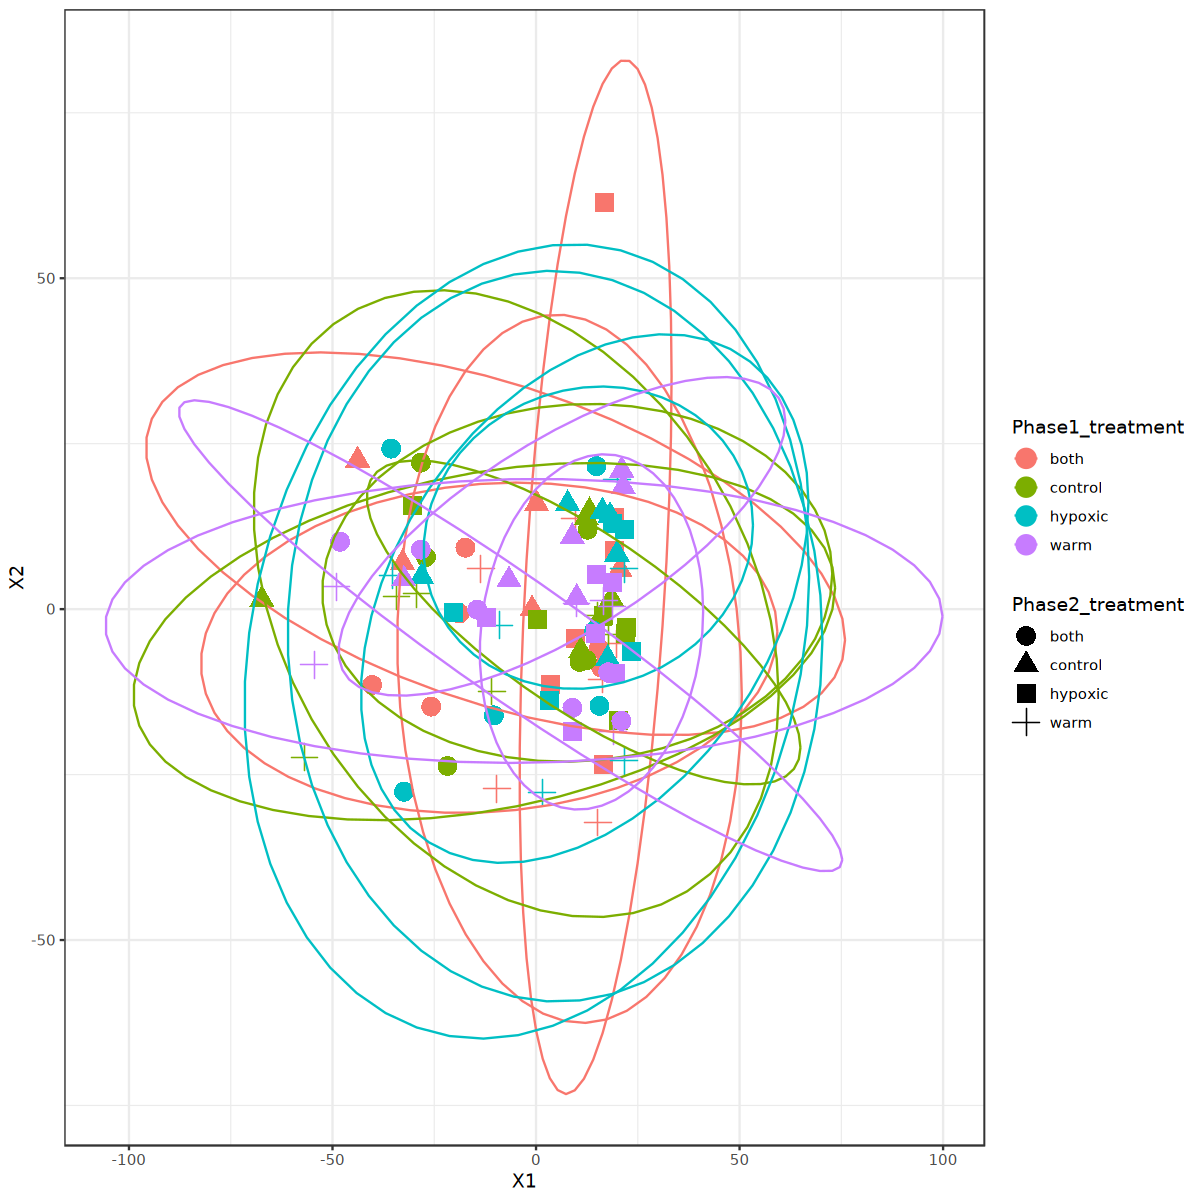

In [32]:
ggplot(mds_filtered, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

okay so it appears when we remove those two seemingly outlier samples, the data gets a little bit 'more clear' and replicates segregate a little better

let's remove those samples (**B5_C1_O09** and **H2_H5_B51**) and re-run DESeq2

## 2. remove outliers, run DESeq again

In [58]:
outlier_samples <- c('B5_C1_O09', 'H2_H5_B51', 'B4_H1_O07')

dds_rm <- dds_filtered[, !colnames(dds_filtered) %in% outlier_samples]
dds_rm <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [59]:
vsd <- vst(dds_rm, blind = FALSE)
vst_mat <- assay(vsd)
head(vst_mat)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.713913,11.525295,11.511540,11.386162,11.130353,11.115028,11.472913,11.188523,11.283291,11.303240,⋯,11.914890,10.817585,11.231177,11.640217,11.514982,11.353019,11.476902,11.339149,11.890411,11.74525
LOC144621269,9.361606,11.283394,11.660350,10.730146,11.696114,10.857468,12.864346,11.193833,9.180794,9.060920,⋯,13.933195,9.005577,9.066434,10.465258,9.308222,9.566349,13.497139,9.164245,10.192421,13.47549
LOC111120925,9.421940,9.203607,10.236099,9.091292,9.161526,9.074791,8.885701,8.953077,8.885701,8.951963,⋯,10.127478,8.885701,9.013541,10.251214,9.460754,9.246471,9.044879,8.955439,9.114561,9.09113
LOC144621283,10.358567,10.711532,10.731171,10.584935,10.663551,10.902110,10.873057,10.245057,10.525323,10.608383,⋯,10.434343,10.830837,10.616876,10.733008,10.708356,10.638003,10.415177,11.142671,10.426917,10.45239
LOC144621276,13.499431,13.541342,13.708980,13.547511,13.817671,13.936176,13.754980,13.274146,13.796639,13.483050,⋯,14.058214,13.361059,13.887532,13.591694,13.156832,13.334180,13.970055,13.424556,13.468906,13.42111
LOC111115920,9.712357,9.765617,9.688047,9.567403,9.506779,9.467176,9.397821,10.140173,9.541051,10.031479,⋯,9.482426,9.552736,9.908304,9.645565,10.162977,10.165302,9.767181,9.892540,9.524763,9.60982


In [198]:
write.csv(vst_mat, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/vst_filtered.csv', row.names = TRUE)

In [60]:
meta_noOutliers <- meta[!rownames(meta) %in% outlier_samples, ]

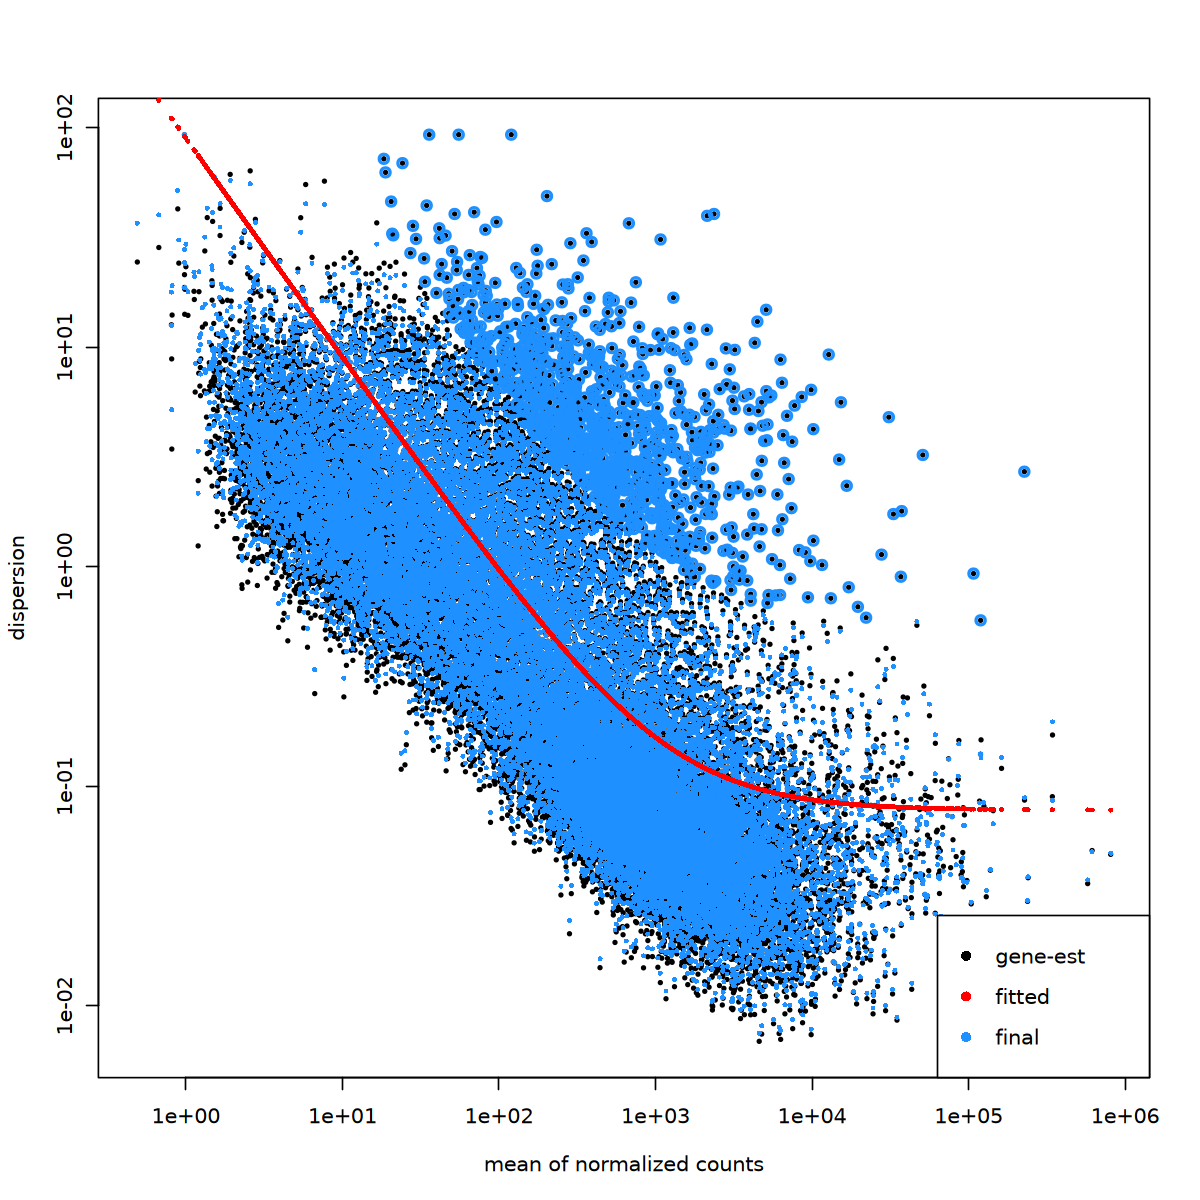

In [61]:
options(repr.plot.height = 10, repr.plot.width = 10)

plotDispEsts(dds_rm)

### PCA

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-12.243457,-7.624064,both:both,both,both,B1_B1_O01
B1_W5_O50,11.009371,4.122663,both:warm,both,warm,B1_W5_O50
B2_B5_O51,14.065626,-12.240189,both:both,both,both,B2_B5_O51
B2_C4_O40,1.984914,7.115702,both:control,both,control,B2_C4_O40
B3_B4_O41,14.422177,5.977055,both:both,both,both,B3_B4_O41
B3_C3_O30,1.079664,4.804655,both:control,both,control,B3_C3_O30


using ntop=500 top features by variance



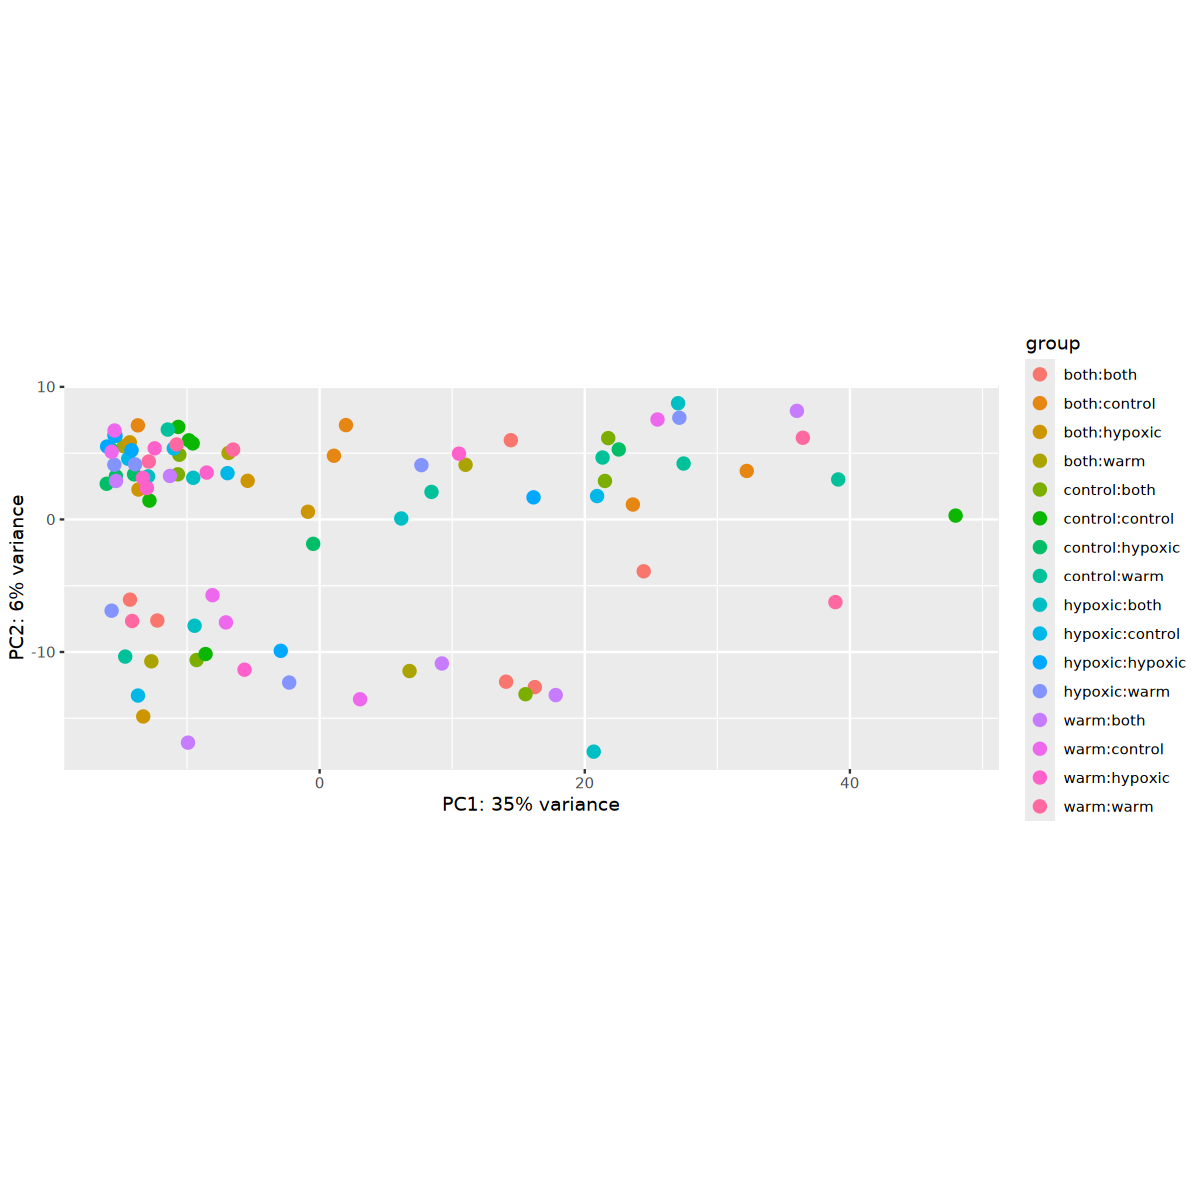

In [62]:
options(repr.plot.height = 10, repr.plot.width = 10)

vsd <- vst(dds_rm, blind=FALSE)
pca_data <- plotPCA(vsd, intgroup=c("Phase1_treatment", "Phase2_treatment"), returnData=TRUE)
head(pca_data)

plotPCA(vsd, intgroup=c("Phase1_treatment", "Phase2_treatment"))

two groups seperating on the y axis

also PC1 explains 34% of the variance

using ntop=500 top features by variance



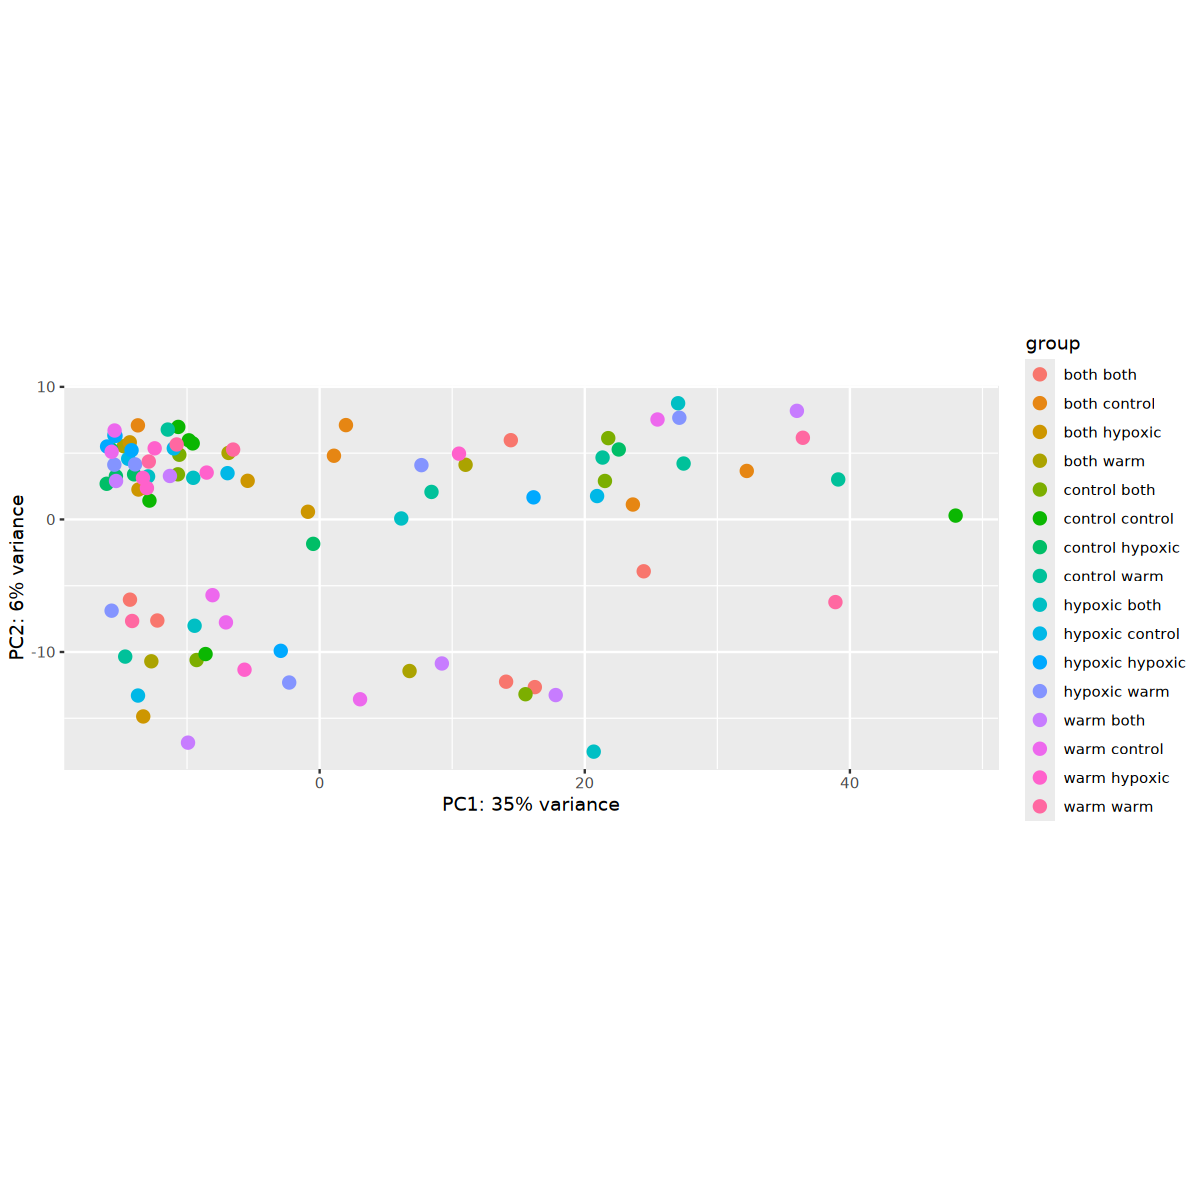

In [63]:
plotPCA(vsd, intgroup=c("complete_trtmt"))

### nMDS
normalize and transform DESeq object using vst (variance stabilized expression matrix)

In [64]:
# variance stabilizing transformation
vsd <- vst(dds_rm, blind = FALSE)
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.713913,11.525295,11.511540,11.386162,11.130353,11.115028,11.472913,11.188523,11.283291,11.303240,⋯,11.914890,10.817585,11.231177,11.640217,11.514982,11.353019,11.476902,11.339149,11.890411,11.74525
LOC144621269,9.361606,11.283394,11.660350,10.730146,11.696114,10.857468,12.864346,11.193833,9.180794,9.060920,⋯,13.933195,9.005577,9.066434,10.465258,9.308222,9.566349,13.497139,9.164245,10.192421,13.47549
LOC111120925,9.421940,9.203607,10.236099,9.091292,9.161526,9.074791,8.885701,8.953077,8.885701,8.951963,⋯,10.127478,8.885701,9.013541,10.251214,9.460754,9.246471,9.044879,8.955439,9.114561,9.09113
LOC144621283,10.358567,10.711532,10.731171,10.584935,10.663551,10.902110,10.873057,10.245057,10.525323,10.608383,⋯,10.434343,10.830837,10.616876,10.733008,10.708356,10.638003,10.415177,11.142671,10.426917,10.45239
LOC144621276,13.499431,13.541342,13.708980,13.547511,13.817671,13.936176,13.754980,13.274146,13.796639,13.483050,⋯,14.058214,13.361059,13.887532,13.591694,13.156832,13.334180,13.970055,13.424556,13.468906,13.42111
LOC111115920,9.712357,9.765617,9.688047,9.567403,9.506779,9.467176,9.397821,10.140173,9.541051,10.031479,⋯,9.482426,9.552736,9.908304,9.645565,10.162977,10.165302,9.767181,9.892540,9.524763,9.60982


In [65]:
# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,73.49295,76.56980,71.68669,76.18283,74.81991,83.06536,75.46366,76.05808,67.64901,⋯,90.49224,72.71271,64.01730,67.52440,64.64210,67.67792,87.00857,70.68000,69.05562,91.14228
B1_W5_O50,73.49295,0.00000,70.62611,62.25933,58.73480,63.95634,64.92787,74.59033,72.15121,70.94227,⋯,74.96837,78.32442,72.34780,72.51993,74.72658,72.19836,76.63275,73.88462,69.08629,73.24192
B2_B5_O51,76.56980,70.62611,0.00000,78.21403,72.89935,77.32797,74.26578,84.01536,87.09788,83.74246,⋯,79.93422,89.23020,81.27882,70.73399,80.59851,82.41645,80.51501,82.70887,79.00462,76.14934
B2_C4_O40,71.68669,62.25933,78.21403,0.00000,65.87547,64.12630,72.57288,72.74782,75.86349,66.13672,⋯,80.53029,73.88641,70.32851,70.32735,71.07014,69.52512,83.46083,68.71040,55.11375,80.69998
B3_B4_O41,76.18283,58.73480,72.89935,65.87547,0.00000,68.52621,70.39734,79.39908,69.35593,74.60860,⋯,73.20860,81.87731,73.41382,76.01770,79.60714,76.67928,72.71767,76.95848,72.33079,73.28368
B3_C3_O30,74.81991,63.95634,77.32797,64.12630,68.52621,0.00000,74.85200,78.20369,79.03500,73.91544,⋯,83.45287,80.18065,67.09566,76.15955,77.15489,73.71686,86.13770,71.02132,71.55870,84.48525


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,14.8375995,12.80330,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-12.0093275,-10.29995,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-16.9260775,11.81584,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-0.1549246,-11.16114,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-15.6765911,-10.10400,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,-0.1042407,-16.61620,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [66]:
mds$Phase1_treatment <- factor(mds$Phase1_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

mds$Phase2_treatment <- factor(mds$Phase2_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

Ignoring unknown labels:
• fill : "Phase 1 Treatment"


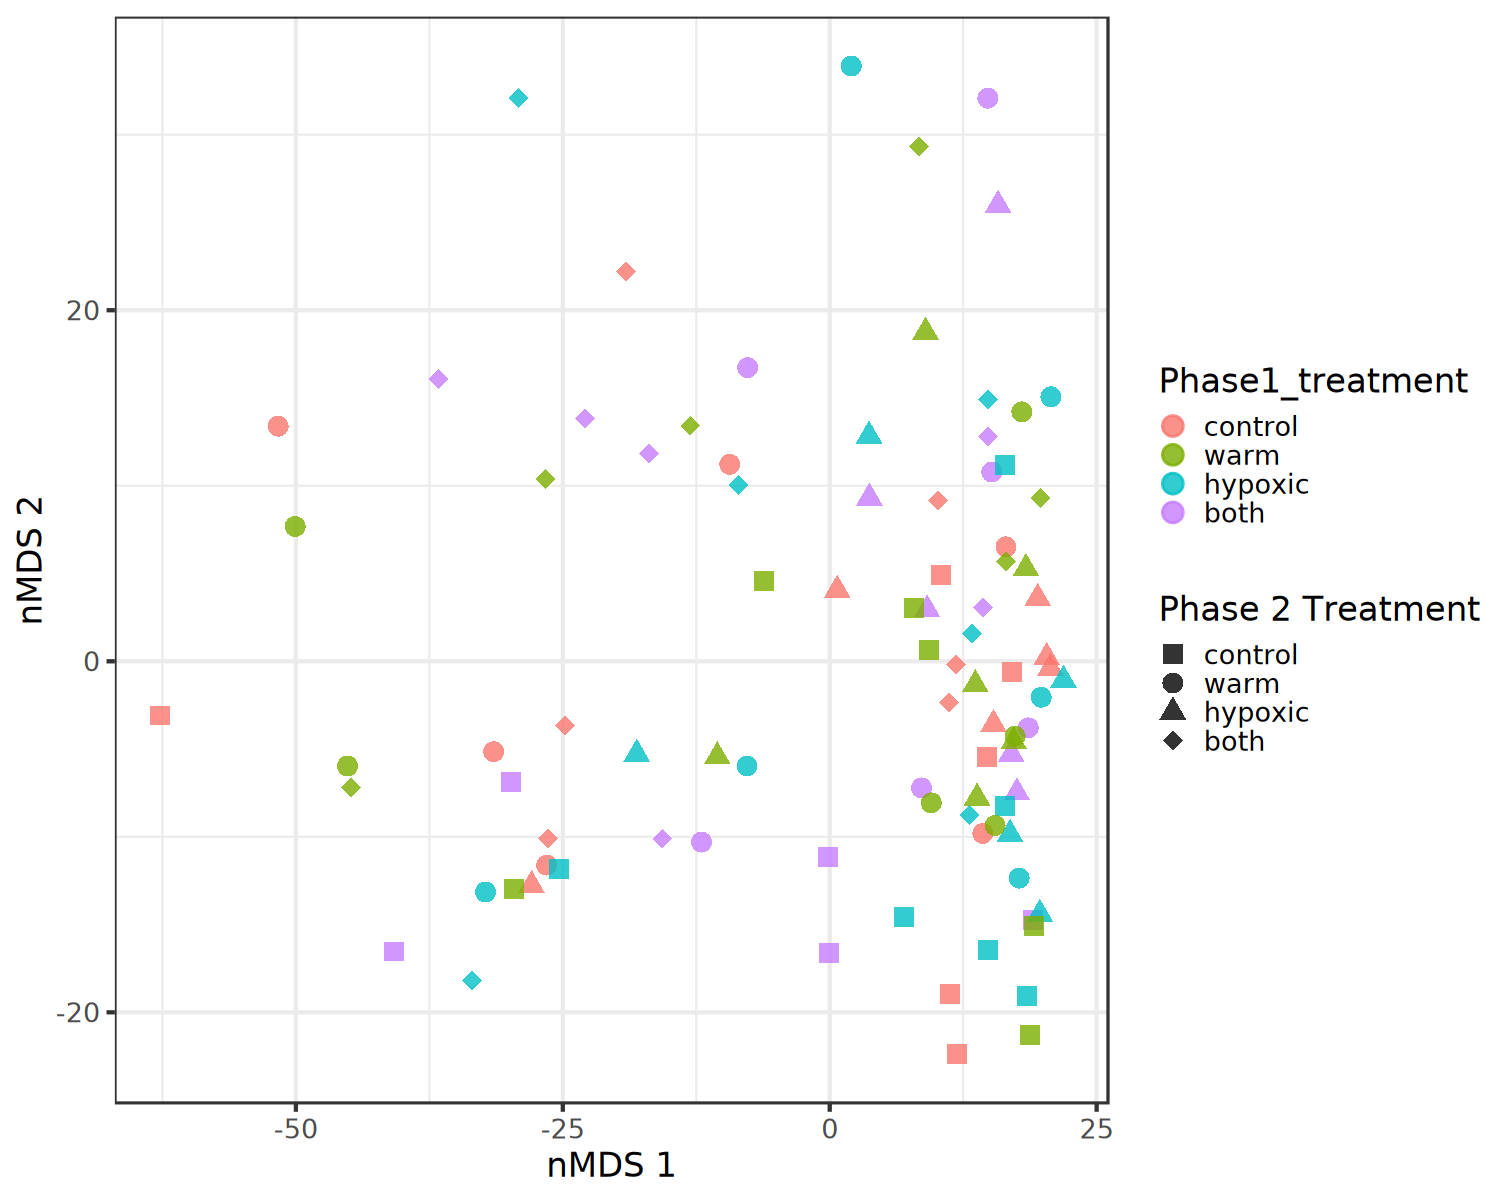

In [69]:
options(repr.plot.width = 12.5, repr.plot.height = 10)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(
    size = 5,
    alpha = 0.8,
  ) +
scale_shape_manual(values = c(15, 16, 17,18)) +
# stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'nMDS 1', 
     y = 'nMDS 2',
    fill = 'Phase 1 Treatment',
    shape = 'Phase 2 Treatment')

nmds.plot

### permANOVA

differences in centroid location(position) between two groups

In [70]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,2528.297,0.009264187,0.8613362,0.715
Phase1_DO,1,2414.549,0.008847390,0.8225846,0.778
Phase2_temp,1,7091.312,0.025983983,2.4158565,0.001
Phase2_DO,1,4633.889,0.016979496,1.5786658,0.033
Phase1_temp:Phase1_DO,1,2367.774,0.008675998,0.8066495,0.821
Phase1_temp:Phase2_temp,1,2068.865,0.007580735,0.7048176,0.968
Phase1_DO:Phase2_temp,1,2337.016,0.008563292,0.7961707,0.852
Phase1_temp:Phase2_DO,1,2224.649,0.008151557,0.7578897,0.921
Phase1_DO:Phase2_DO,1,3002.743,0.011002649,1.0229695,0.338


significant effects:
- phase2_temp (2.6% of variance)
- phase2_DO (1.7% of variance)
- phase2_temp:phase2_DO (1.7% of variance)

reformatting the nmds to look at the sig. effects of phase 2 temp and DO

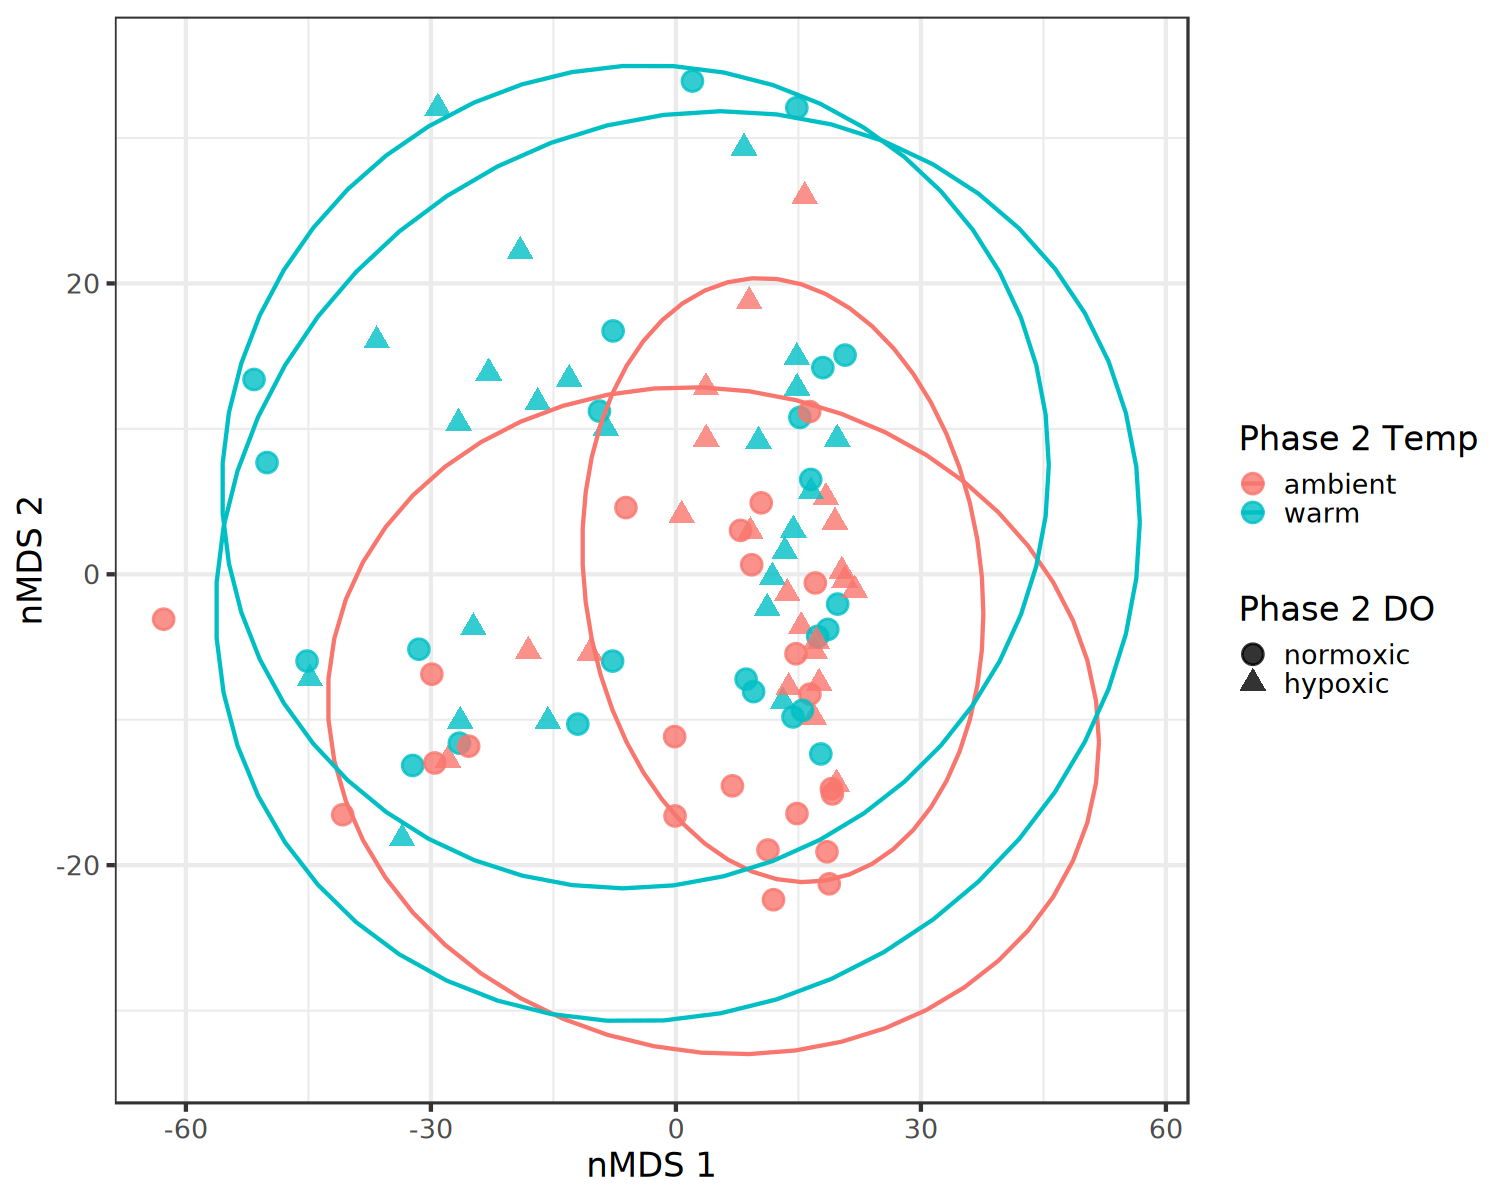

In [72]:
options(repr.plot.width = 12.5, repr.plot.height = 10)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase2_temp, shape = Phase2_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'nMDS 1', 
     y = 'nMDS 2',
    col = 'Phase 2 Temp',
    shape = 'Phase 2 DO')

nmds.plot2

the blue circles, which are phase 2 warm temp treatment, seem to overlap and have a large dispersion

meanwhile, the red circles, which are phase 2 ambient temp treatment, have some overlap but different dispersion patterns - ambient and hypoxic in phase 2 result in tighter clustering, while ambient and normoxic in phase 2 have wider dispersion

in ambient temperatures, oysters have different transcriptomic profiles depending on the DO treatment. in warm temperatures, the effect of DO is negligible - so warming supersedes DO?

### heatmap 
of sample-to-sample distances using the variance stabilizing transformed values


following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [73]:
# normalization & transformation
vsd <- vst(dds_rm, blind = FALSE)

# calculate sample distances
sample_dists <- dist(t(assay(vsd)))
head(sample_dists)

[1] 73.49295 76.56980 71.68669 76.18283 74.81991 83.06536

In [74]:
head(vsd)

class: DESeqTransform 
dim: 6 93 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(93): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

In [77]:
head(meta_noOutliers)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


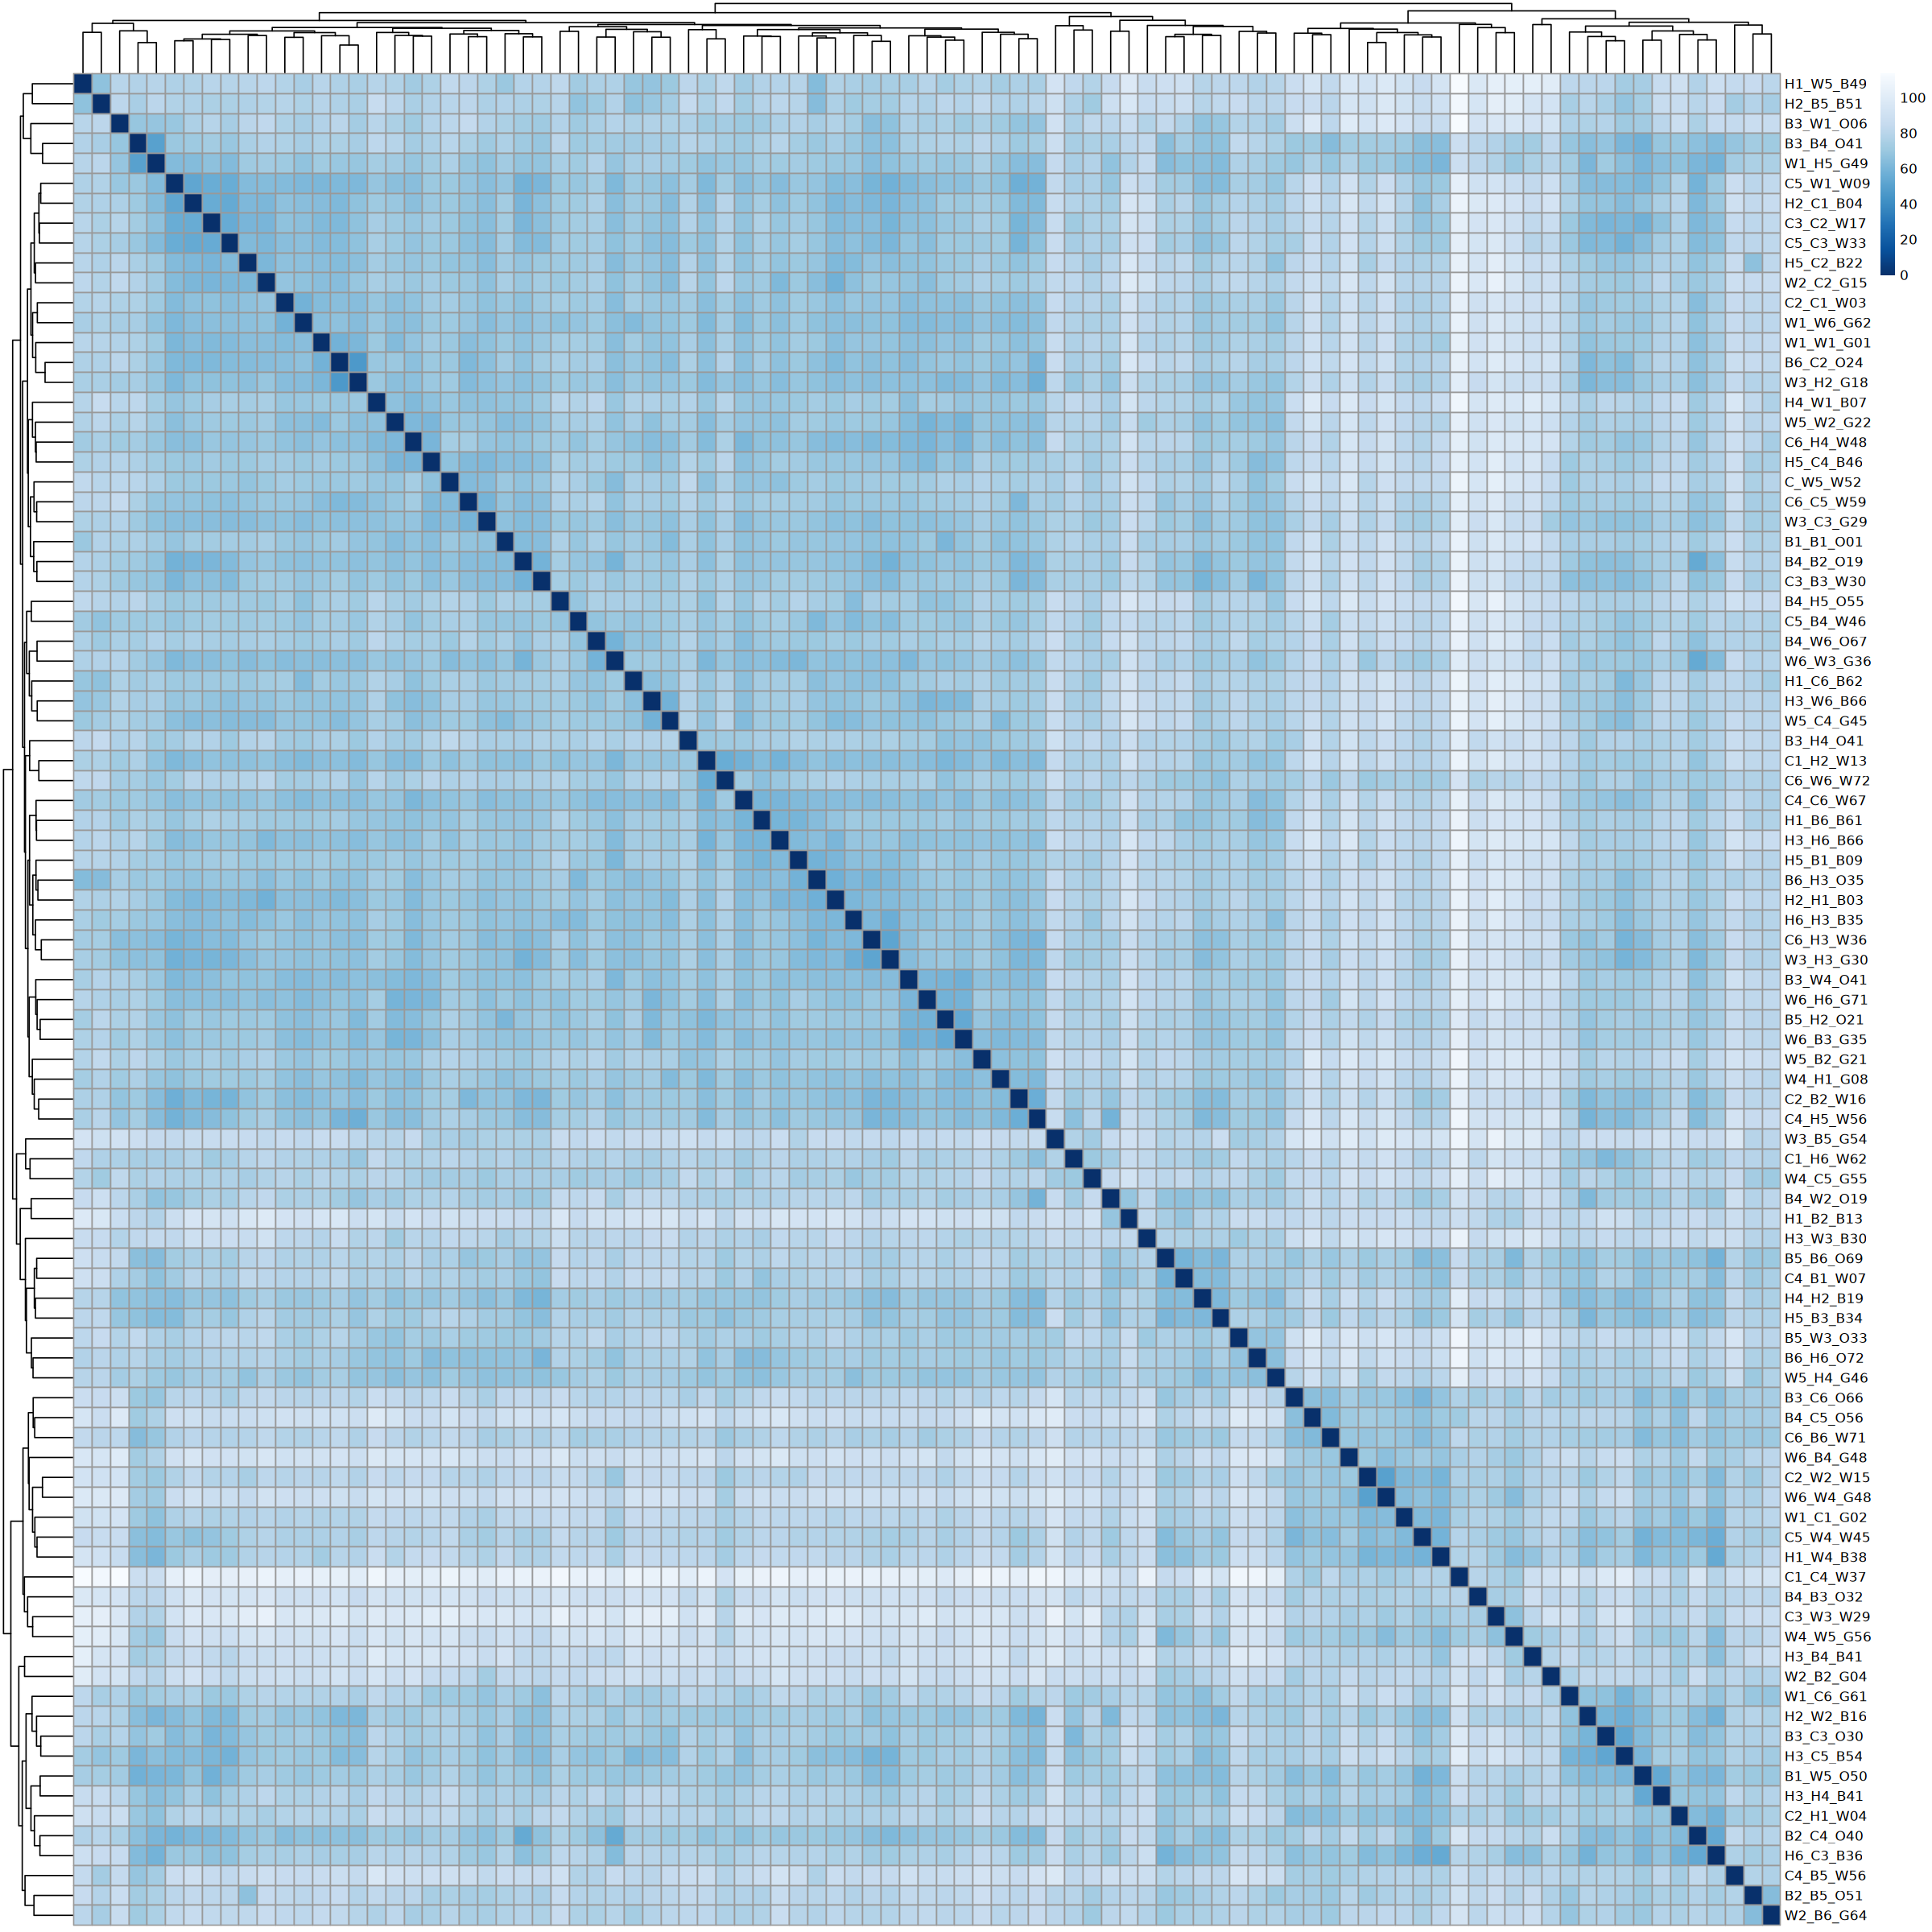

In [82]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

In [83]:
resultsNames(dds_rm)

[1] "Intercept"                                  
 [2] "complete_trtmt_both.control_vs_both.both"   
 [3] "complete_trtmt_both.hypoxic_vs_both.both"   
 [4] "complete_trtmt_both.warm_vs_both.both"      
 [5] "complete_trtmt_control.both_vs_both.both"   
 [6] "complete_trtmt_control.control_vs_both.both"
 [7] "complete_trtmt_control.hypoxic_vs_both.both"
 [8] "complete_trtmt_control.warm_vs_both.both"   
 [9] "complete_trtmt_hypoxic.both_vs_both.both"   
[10] "complete_trtmt_hypoxic.control_vs_both.both"
[11] "complete_trtmt_hypoxic.hypoxic_vs_both.both"
[12] "complete_trtmt_hypoxic.warm_vs_both.both"   
[13] "complete_trtmt_warm.both_vs_both.both"      
[14] "complete_trtmt_warm.control_vs_both.both"   
[15] "complete_trtmt_warm.hypoxic_vs_both.both"   
[16] "complete_trtmt_warm.warm_vs_both.both"

### MA plot
of one example comparison between HC and CC

In [84]:
# Unshrunken results for your contrast/interaction term
res <- results(dds_rm, contrast = c("complete_trtmt", "hypoxic.control", "control.control"))
# or for an interaction/complex contrast:
# res <- results(dds, name = "phase1stressorA.phase2stressorB")

# Shrunken with ashr — works with contrast= or name= directly, no coef restriction
res_shrunk <- lfcShrink(dds_rm, contrast = c("complete_trtmt", "hypoxic.control", "control.control"), type = "ashr")
# or: res_shrunk <- lfcShrink(dds, res = res, type = "ashr")

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



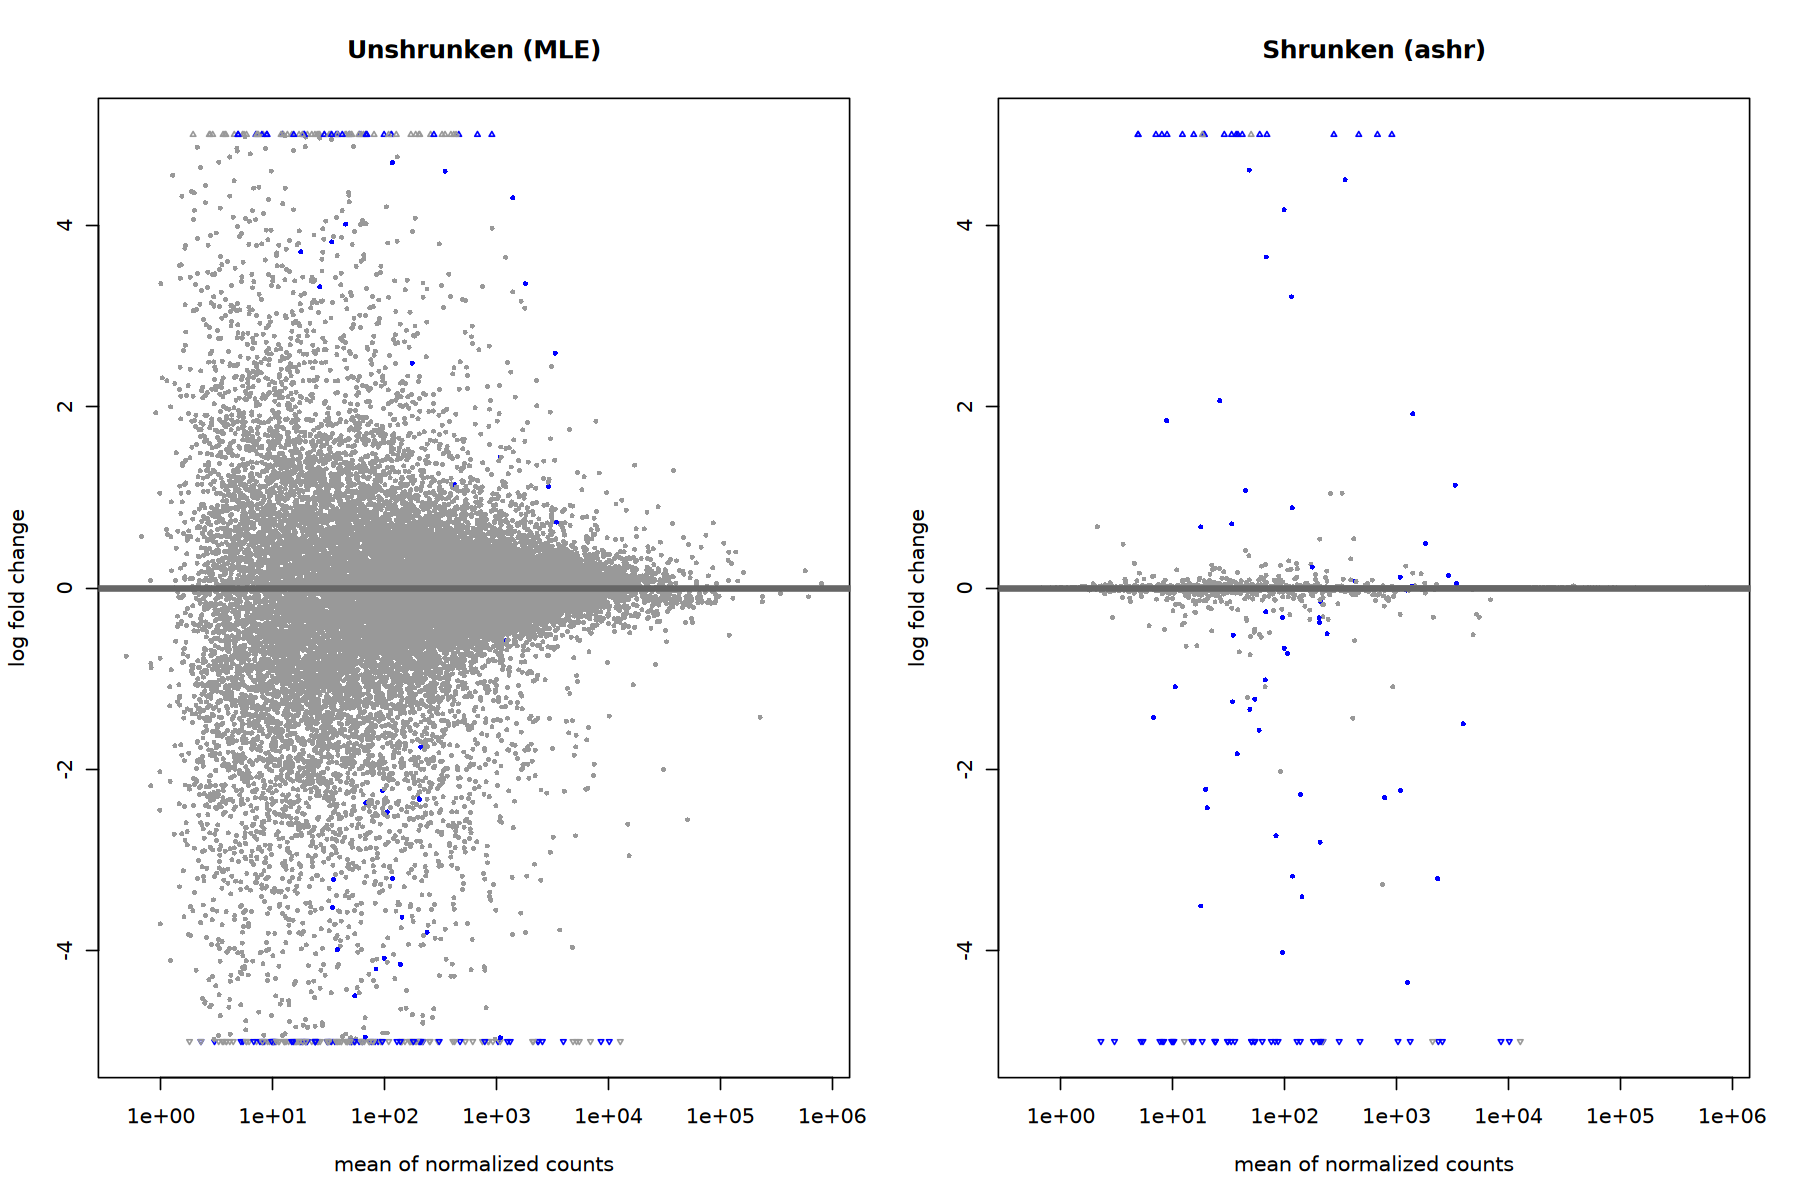

In [85]:
options(repr.plot.height = 10, repr.plot.width = 15)
par(mfrow = c(1, 2))
DESeq2::plotMA(res, ylim = c(-5, 5), main = "Unshrunken (MLE)")
DESeq2::plotMA(res_shrunk, ylim = c(-5, 5), main = "Shrunken (ashr)")

shrinking collapes the grey cloud to LFC = 0, so that genes with large LFC and low mean counts aren't showing up as DEGs (likely due to noise)

this shouldn't change the number of DEGs really - checking below:

In [86]:
sum(res$padj < 0.05, na.rm = TRUE)
sum(res_shrunk$padj < 0.05, na.rm = TRUE)  # should be ~identical to above

# now check with your actual FC cutoff
sum(res_shrunk$padj < 0.05 & abs(res_shrunk$log2FoldChange) > 1, na.rm = TRUE)
sum(res$padj < 0.05 & abs(res$log2FoldChange) > 1, na.rm = TRUE)  # unshrunken FC filter, for comparison

[1] 93

[1] 93

[1] 90

[1] 92

## Pairwise comparisons

### 1. Effect of single exposure on GE after a period of recovery
- CC vs. WC
- CC vs. HC
- CC vs. BC

**CC vs. WC**

In [88]:
options(repr.plot.width = 5, repr.plot.height = 10)

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 37, 0.14%
LFC < 0 (down)     : 47, 0.18%
outliers [1]       : 83, 0.32%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1973.3604,-1.224836e-04,0.006461219,0.4595314,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2488.6830,-2.136480e-03,0.082050833,0.1756583,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,130.7124,-3.082822e-05,0.035309333,0.9670705,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,867.0705,-5.016063e-05,0.006153094,0.7627174,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12226.5972,7.458174e-05,0.005965392,0.7276215,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,172.2441,1.833695e-04,0.011024407,0.2903760,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


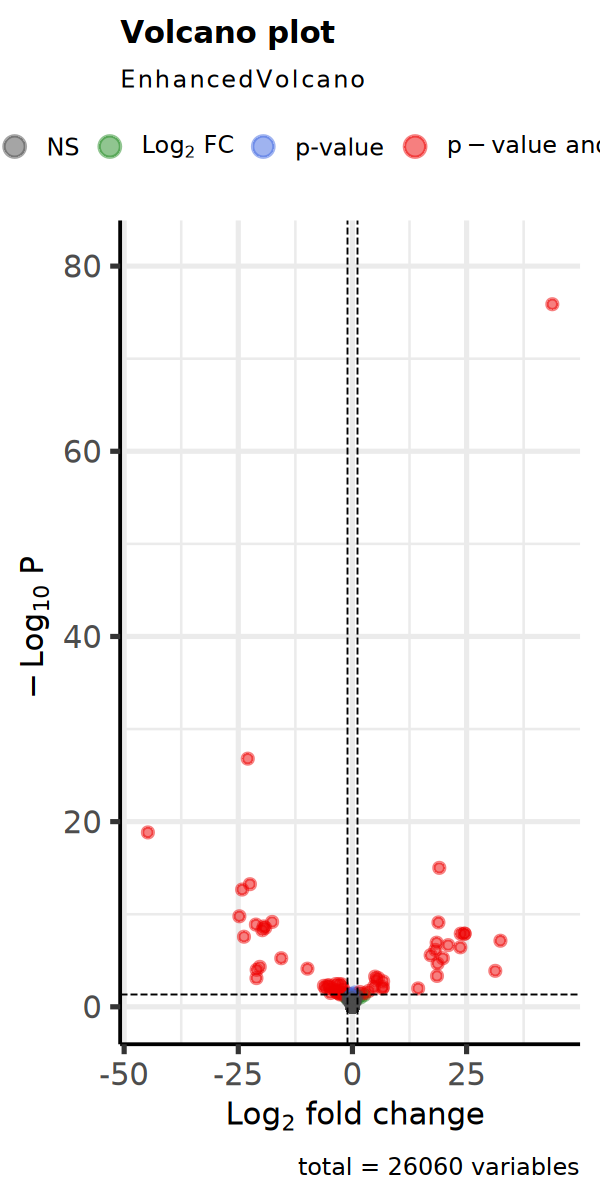

In [89]:
res.wc.cc <- lfcShrink(dds_rm, 
                       contrast= c('complete_trtmt', 'warm.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.wc.cc)

EnhancedVolcano(res.wc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.cc <- merge(res.wc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.cc)[1] <- 'Gene'

head(res.wc.cc)

In [90]:
write.csv(res.wc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_cc.csv', row.names = FALSE)

**CC vs. HC**

In [ ]:
res.hc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.hc.cc)

EnhancedVolcano(res.hc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hc.cc <- merge(res.hc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hc.cc)[1] <- 'Gene'

head(res.hc.cc)

In [ ]:
write.csv(res.hc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hc_cc.csv', row.names = FALSE)

**CC vs. BC**

In [ ]:
res.bc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.bc.cc)

EnhancedVolcano(res.bc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.cc <- merge(res.bc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.cc)[1] <- 'Gene'

head(res.bc.cc)

In [ ]:
write.csv(res.bc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_cc.csv', row.names = FALSE)

### 2. Effect of single exposure experienced only later in life
- CC vs. CW
- CC vs. CH
- CC vs. CB

**CC vs. CW**

In [ ]:
res.cw.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cw.cc)

EnhancedVolcano(res.cw.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.cc <- merge(res.cw.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.cc)[1] <- 'Gene'

head(res.cw.cc)

In [ ]:
write.csv(res.cw.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_cc.csv', row.names = FALSE)

**CC vs. CH**

In [ ]:
res.ch.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.ch.cc)

EnhancedVolcano(res.ch.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ch.cc <- merge(res.ch.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ch.cc)[1] <- 'Gene'

head(res.ch.cc)

In [ ]:
write.csv(res.ch.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ch_cc.csv', row.names = FALSE)

**CC vs. CB**

In [ ]:
res.cb.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cb.cc)

EnhancedVolcano(res.cb.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.cc <- merge(res.cb.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.cc)[1] <- 'Gene'

head(res.cb.cc)

In [ ]:
write.csv(res.cb.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_cc.csv', row.names = FALSE)

### 3. Timing of Stress Exposure
How does GE change depending on when stress is experienced (when all oysters only experience stress once)?
- CH vs. HC
- CW vs. WC
- CB vs. BC

**CH vs. HC**

In [ ]:
res.ch.hc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.ch.hc)

EnhancedVolcano(res.ch.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ch.hc <- merge(res.ch.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ch.hc)[1] <- 'Gene'

head(res.ch.hc)

In [ ]:
write.csv(res.ch.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ch_hc.csv', row.names = FALSE)

**CW vs. WC**

In [ ]:
res.cw.wc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'warm.control'), # WC is the "control"
                     type = 'ashr')

summary(res.cw.wc)

EnhancedVolcano(res.cw.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.wc <- merge(res.cw.wc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.wc)[1] <- 'Gene'

head(res.cw.wc)

In [ ]:
write.csv(res.cw.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_wc.csv', row.names = FALSE)

**CB vs. BC**

In [ ]:
res.cb.bc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'both.control'), # BC is the "control"
                     type = 'ashr')

summary(res.cb.bc)

EnhancedVolcano(res.cb.bc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.bc <- merge(res.cb.bc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.bc)[1] <- 'Gene'

head(res.cb.bc)

In [ ]:
write.csv(res.cb.bc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_bc.csv', row.names = FALSE)

### 4. No stress vs. most stress
- CC vs. WW
- CC vs. HH
- CC vs. BB

**CC vs. WW**

In [ ]:
res.cc.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cc.ww)

EnhancedVolcano(res.cc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.ww <- merge(res.cc.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.ww)[1] <- 'Gene'

head(res.cc.ww)

In [ ]:
write.csv(res.cc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ww_cc.csv', row.names = FALSE)

**CC vs. HH**

In [ ]:
res.cc.hh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cc.hh)

EnhancedVolcano(res.cc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.hh <- merge(res.cc.hh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.hh)[1] <- 'Gene'

head(res.cc.hh)

In [ ]:
write.csv(res.cc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hh_cc.csv', row.names = FALSE)

**CC vs. BB**

In [ ]:
res.cc.bb <- lfcShrink(dds_rm, coef='complete_trtmt_control.control_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.cc.bb)

EnhancedVolcano(res.cc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.bb <- merge(res.cc.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.bb)[1] <- 'Gene'

head(res.cc.bb)

switch LFC direction so CC is the baseline (deseq recognizes as bb as the baseline rn)

In [ ]:
cc.bb.df <- as.data.frame(res.cc.bb) %>% # create df
mutate(log2FoldChange = log2FoldChange * -1) # multiple by -1 to make pos to neg and vice versa 

# validate
head(res.cc.bb)
head(cc.bb.df)

In [ ]:
write.csv(cc.bb.df, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bb_cc.csv', row.names = FALSE)

### 5. Effect of initial exposure on response in later exposure
(also gets at the effect of priming to stress)

#### 5A. Matched stressors
Oyster is primed with a stress, and experiences the *same* stressor again
- HH vs. CH
- WW vs. CW
- BB vs. CB

**HH vs. CH**

In [ ]:
res.hh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.hh.ch)

EnhancedVolcano(res.hh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hh.ch <- merge(res.hh.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hh.ch)[1] <- 'Gene'

head(res.hh.ch)

In [ ]:
write.csv(res.hh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hh_ch.csv', row.names = FALSE)

**WW vs. CW**

In [ ]:
res.ww.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.ww.cw)

EnhancedVolcano(res.ww.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ww.cw <- merge(res.ww.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ww.cw)[1] <- 'Gene'

head(res.ww.cw)

In [ ]:
write.csv(res.ww.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ww_cw.csv', row.names = FALSE)

**BB vs. CB**

In [ ]:
res.cb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_control.both_vs_both.both', # BB is the "control"
                       type = 'ashr')

summary(res.cb.bb)

EnhancedVolcano(res.cb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.bb <- merge(res.cb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.bb)[1] <- 'Gene'

head(res.cb.bb)

In [ ]:
write.csv(res.cb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_bb.csv', row.names = FALSE)

#### 5B. Semi-matched priming: in context of later *single* stress
- CH vs. BH
- CW vs. BW

**CH vs. BH**

In [ ]:
res.bh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.bh.ch)

EnhancedVolcano(res.bh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bh.ch <- merge(res.bh.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bh.ch)[1] <- 'Gene'

head(res.bh.ch)

In [ ]:
write.csv(res.bh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bh_ch.csv', row.names = FALSE)

**CW vs. BW**

In [ ]:
res.bw.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.bw.cw)

EnhancedVolcano(res.bw.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bw.cw <- merge(res.bw.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bw.cw)[1] <- 'Gene'

head(res.bw.cw)

In [ ]:
write.csv(res.bw.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bw_cw.csv', row.names = FALSE)

#### 5C. Semi-matched priming: in context of later *multiple* stress
- CB vs. WB
- CB vs. HB

**CB vs. WB**

In [ ]:
res.wb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.both', 'control.both'), # CB is the "control"
                       type = 'ashr')

summary(res.wb.cb)

EnhancedVolcano(res.wb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.cb <- merge(res.wb.cb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.cb)[1] <- 'Gene'

head(res.wb.cb)

In [ ]:
write.csv(res.wb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_cb.csv', row.names = FALSE)

**CB vs. HB**

In [ ]:
res.hb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.both', 'control.both'), # CB is the "control"
                       type = 'ashr')

summary(res.hb.cb)

EnhancedVolcano(res.hb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.cb <- merge(res.hb.cb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.cb)[1] <- 'Gene'

head(res.hb.cb)

In [ ]:
write.csv(res.hb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_cb.csv', row.names = FALSE)

### 6. Effect of initial exposure on subsequent response to stress
Oysters all experience the same early stressor, but either return to that stressor or experience control conditions
- HC vs. HH
- WC vs. WW
- BB vs. BC

**HC vs. HH**

In [ ]:
res.hc.hh <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.control', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr')

summary(res.hc.hh)

EnhancedVolcano(res.hc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hc.hh <- merge(res.hc.hh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hc.hh)[1] <- 'Gene'

head(res.hc.hh)

In [ ]:
write.csv(res.hc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hc_hh.csv', row.names = FALSE)

**WC vs. WW**

In [ ]:
res.wc.ww <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.control', 'warm.warm'), # WW is the "control"
                     type = 'ashr')

summary(res.wc.ww)

EnhancedVolcano(res.wc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.ww <- merge(res.wc.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.ww)[1] <- 'Gene'

head(res.wc.ww)

In [ ]:
write.csv(res.wc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_ww.csv', row.names = FALSE)

**BC vs. BB**

In [ ]:
res.bc.bb <- lfcShrink(dds_rm, coef = 'complete_trtmt_both.control_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.bc.bb)

EnhancedVolcano(res.bc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.bb <- merge(res.bc.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.bb)[1] <- 'Gene'

head(res.bc.bb)

In [ ]:
write.csv(res.bc.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_bb.csv', row.names = FALSE)

### 7. Effect of initial single/multiple stress on response in ...
Is it better to be primed with a single stressor or multiple stressor, depending on the context of the future enviornment (single/multiple stressor)?

#### 7A. ...later *single* stress
Oyster is primed with either multiple or a single stressors, and then experiences only a sinlge stressor later
- BH vs. HH
- BW vs. WW

**BH vs. HH**

In [ ]:
res.hh.bh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr')

summary(res.hh.bh)

EnhancedVolcano(res.hh.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hh.bh <- merge(res.hh.bh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hh.bh)[1] <- 'Gene'

head(res.hh.bh)

In [ ]:
write.csv(res.hh.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bh_hh.csv', row.names = FALSE)

**BW vs. WW**

In [ ]:
res.bw.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'warm.warm'), # WW is the "control"
                     type = 'ashr')

summary(res.bw.ww)

EnhancedVolcano(res.bw.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bw.ww <- merge(res.bw.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bw.ww)[1] <- 'Gene'

head(res.bw.ww)

In [ ]:
write.csv(res.bw.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bw_ww.csv', row.names = FALSE)

#### 7B. ...later *multiple* stressors
Oyster is primed with either multiple or a single stressors, and then experiences multiple stressors later
- HB vs. BB
- WB vs. BB

**HB vs. BB**

In [ ]:
res.hb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_hypoxic.both_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.hb.bb)

EnhancedVolcano(res.hb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.bb <- merge(res.hb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.bb)[1] <- 'Gene'

head(res.hb.bb)

In [ ]:
write.csv(res.hb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_bb.csv', row.names = FALSE)

**WB vs. BB**

In [ ]:
res.wb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_warm.both_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.wb.bb)

EnhancedVolcano(res.wb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.bb <- merge(res.wb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.bb)[1] <- 'Gene'

head(res.wb.bb)

In [ ]:
write.csv(res.wb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_bb.csv', row.names = FALSE)

### 8. Shared/Unique responses among stressors with ...

#### 8A. ...different *early* stressors
>can compare these with the phase 1 vs. phase 1 DEGs to see if there are similarities
- WC vs. HC: single early stress
- BC vs. HC: mulitple vs. single
- BC vs. WC: multiple vs. single

**WC vs. HC**

In [ ]:
res.wc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.wc.hc)

EnhancedVolcano(res.wc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.hc <- merge(res.wc.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.hc)[1] <- 'Gene'

head(res.wc.hc)

In [ ]:
write.csv(res.wc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_hc.csv', row.names = FALSE)

**BC vs. HC**

In [ ]:
res.bc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.bc.hc)

EnhancedVolcano(res.bc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.hc <- merge(res.bc.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.hc)[1] <- 'Gene'

head(res.bc.hc)

In [ ]:
write.csv(res.bc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_hc.csv', row.names = FALSE)

**BC vs. WC**

In [ ]:
res.bc.wc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'warm.control'), # WC is the "control"
                     type = 'ashr')

summary(res.bc.wc)

EnhancedVolcano(res.bc.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.wc <- merge(res.bc.wc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.wc)[1] <- 'Gene'

head(res.bc.wc)

In [ ]:
write.csv(res.bc.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_wc.csv', row.names = FALSE)

#### 8B. ...different *late* stressors
- CW vs. CH: single early stress
- CB vs. CH: mulitple vs. single
- CB vs. CW: multiple vs. single

**CW vs. CH**

In [ ]:
res.cw.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.warm', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.cw.ch)

EnhancedVolcano(res.cw.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.ch <- merge(res.cw.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.ch)[1] <- 'Gene'

head(res.cw.ch)

In [ ]:
write.csv(res.cw.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_ch.csv', row.names = FALSE)

**CB vs. CH**

In [ ]:
res.cb.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.cb.ch)

EnhancedVolcano(res.cb.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.ch <- merge(res.cb.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.ch)[1] <- 'Gene'

head(res.cb.ch)

In [ ]:
write.csv(res.cb.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_ch.csv', row.names = FALSE)

**CB vs. CW**

In [ ]:
res.cb.cw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.cb.cw)

EnhancedVolcano(res.cb.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.cw <- merge(res.cb.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.cw)[1] <- 'Gene'

head(res.cb.cw)

In [ ]:
write.csv(res.cb.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_cw.csv', row.names = FALSE)

### 9. Effect of the order of stressors
Does the order of when stress is experienced matter? Maybe one stressor is an informative cue for a later environmnet?
- WH vs. HW
- WB vs. BW
- HB vs. BH

**WH vs. HW**

In [ ]:
res.wh.hw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.hypoxic', 'hypoxic.warm'), # HW is the "control"
                     type = 'ashr')

summary(res.wh.hw)

EnhancedVolcano(res.wh.hw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wh.hw <- merge(res.wh.hw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wh.hw)[1] <- 'Gene'

head(res.wh.hw)

In [ ]:
write.csv(res.wh.hw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wh_hw.csv', row.names = FALSE)

**WB vs. BW**

In [ ]:
res.wb.bw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.both', 'both.warm'), # BW is the "control"
                     type = 'ashr')

summary(res.wb.bw)

EnhancedVolcano(res.wb.bw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.bw <- merge(res.wb.bw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.bw)[1] <- 'Gene'

head(res.wb.bw)

In [ ]:
write.csv(res.wb.bw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_bw.csv', row.names = FALSE)

**HB vs. BH**

In [ ]:
res.hb.bh <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'hypoxic.both', 'both.hypoxic'), # BH is the "control"
                     type = 'ashr')

summary(res.hb.bh)

EnhancedVolcano(res.hb.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.bh <- merge(res.hb.bh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.bh)[1] <- 'Gene'

head(res.hb.bh)

In [ ]:
write.csv(res.hb.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_bh.csv', row.names = FALSE)

### temperature and DO treatments
looking at the effects of temperature and DO in an isolated manner

#### phase 1 temp
ambient vs. warm

regardless of phase 2 treatments or phase 1 DO

In [ ]:
design(dds_rm) <- ~ Phase1_temp
dds_p1temp <- DESeq(dds_rm)

In [ ]:
p1_temp.res <- lfcShrink(dds_p1temp, contrast = c('Phase1_temp', 'warm', 'ambient'),
                     type = 'ashr')

summary(p1_temp.res)

EnhancedVolcano(p1_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_temp.res <- merge(p1_temp.res, counts(dds_p1temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_temp.res)[1] <- 'Gene'

head(p1_temp.res)

In [ ]:
as.data.frame(p1_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 14 DEGs

In [ ]:
write.csv(p1_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_temp.csv', row.names = FALSE)

#### phase 1 DO
normoxic vs. hypoxic

In [ ]:
design(dds_rm) <- ~ Phase1_DO
dds_p1DO <- DESeq(dds_rm)

In [ ]:
p1_DO.res <- lfcShrink(dds_p1DO, contrast = c('Phase1_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(p1_DO.res)

EnhancedVolcano(p1_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_DO.res <- merge(p1_DO.res, counts(dds_p1DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_DO.res)[1] <- 'Gene'

head(p1_DO.res)

a couple more DEGs, but still not a ton - to be expected, since we think GE is more short term

In [ ]:
as.data.frame(p1_DO.res) %>%
filter(abs(log2FoldChange) >= 1 & padj <= 0.05) %>%
dim()

# 12 DEGs

In [ ]:
write.csv(p1_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_DO.csv', row.names = FALSE)

#### phase 2 temp
ambient vs. warm

regardless of phase 1 treatments or phase 2 DO

In [ ]:
design(dds_rm) <- ~ Phase2_temp
dds_p2temp <- DESeq(dds_rm)

In [ ]:
p2_temp.res <- lfcShrink(dds_p2temp, contrast = c('Phase2_temp', 'warm', 'ambient'), 
                     type = 'ashr')

summary(p2_temp.res)

EnhancedVolcano(p2_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_temp.res <- merge(p2_temp.res, counts(dds_p2temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_temp.res)[1] <- 'Gene'

head(p2_temp.res)

In [ ]:
as.data.frame(p2_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 80 DEGs!

In [ ]:
write.csv(p2_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p2_temp.csv', row.names = FALSE)

#### phase 2 DO
normoxic vs. hypoxic

regardless of phase 1 treatments or phase 2 temperatures

In [ ]:
design(dds_rm) <- ~ Phase2_DO
dds_p2DO <- DESeq(dds_rm)

In [ ]:
p2_DO.res <- lfcShrink(dds_p2DO, contrast = c('Phase2_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(p2_DO.res)

EnhancedVolcano(p2_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_DO.res <- merge(p2_DO.res, counts(dds_p2DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_DO.res)[1] <- 'Gene'

head(p2_DO.res)

In [ ]:
as.data.frame(p2_DO.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 29 DEGs!

In [ ]:
write.csv(p2_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p2_DO.csv', row.names = FALSE)

# I STOPPED HERE

### nMDS of only significant DEGs from isolated treatments

shouldn't matter which DESeq function I run, since we only need vst which is the normalized expression - should return the same numbers/counts 

In [146]:
# variance stabilizing transformation
vsd <- vst(dds.noOutliers) # from full DESeq function, without the 2 outlier samples
head(assay(vsd))

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'nrow': object 'dds.noOutliers' not found


get list of DEGs identified in the 'isolated' treatments (otherwise, there's just a million DEGs)

In [42]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
names(geneList)

[1] "p1_DO"   "p1_temp" "p2_DO"   "p2_temp"

In [43]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::filter(padj < 0.05 & abs(log2FoldChange) > 1) %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 290 total DEGs
head(all_degs)

[1] 265

[1] "LOC111104012" "LOC111102592" "LOC144624804" "LOC144625490" "LOC144625901"
[6] "LOC111101301"

In [44]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 290 total DEGs kept
head(degs_vsd) 

[1] 265  94

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111102506,10.380840,9.560323,13.467640,9.095155,10.970108,8.935006,9.062335,10.197227,11.499914,9.047712,⋯,9.050487,9.415516,9.525608,10.696301,9.276084,9.537034,10.351851,9.426189,9.549025,9.346426
LOC111103173,8.347567,8.247518,8.279739,8.161861,8.161861,8.321493,8.161861,8.161861,8.161861,8.995706,⋯,8.161861,8.161861,8.161861,8.471088,8.304568,8.161861,8.291656,8.161861,8.339826,8.338495
LOC111103490,12.325820,13.319562,13.893435,11.230966,12.825426,12.065763,12.362042,11.998235,11.651213,10.530309,⋯,11.425075,10.593363,11.145859,11.228763,12.027792,11.018941,12.625862,11.607018,11.498946,13.141607
LOC144622059,8.327985,8.876399,8.245225,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,⋯,10.237259,8.161861,8.296431,8.283347,8.161861,8.161861,9.787217,8.161861,8.161861,10.179552
LOC111105131,8.396666,8.403887,8.867176,8.300329,8.694998,8.367875,8.454862,8.161861,8.531140,8.403151,⋯,9.441800,8.440138,8.161861,8.161861,8.161861,8.314577,9.782977,8.161861,8.161861,8.610659
LOC111104543,8.161861,8.445538,8.524332,8.321730,8.619704,8.572847,8.438158,8.161861,8.161861,8.161861,⋯,9.320533,8.161861,8.161861,8.404617,8.422161,8.314577,8.779810,8.161861,8.161861,10.026920


In [45]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,12.575673,16.82096,12.932864,18.58007,12.594205,14.322617,12.745796,11.877148,14.74850,⋯,27.36305,12.869791,12.07491,13.119530,12.501106,11.169574,25.15713,12.550227,13.346193,29.06447
B1_W5_O50,12.57567,0.000000,14.84429,8.567808,15.52108,8.574989,7.974597,8.088239,8.893891,12.04086,⋯,23.28776,9.808964,10.29981,8.776904,10.301848,9.748675,23.38100,9.719817,9.762422,24.77291
B2_B5_O51,16.82096,14.844288,0.00000,17.181774,16.99998,15.616050,14.885430,15.458491,16.149148,18.88176,⋯,22.43185,17.067327,17.58493,14.626084,16.882472,16.532962,21.64151,16.288461,16.925990,24.29982
B2_C4_O40,12.93286,8.567808,17.18177,0.000000,18.24160,8.873988,11.237758,9.261132,10.947797,10.92293,⋯,25.83020,9.409984,10.18547,9.371928,8.983627,9.903190,25.75128,8.394751,7.448790,27.16068
B3_B4_O41,18.58007,15.521084,16.99998,18.241597,0.00000,17.531613,16.313913,18.262602,17.093566,20.59936,⋯,17.40215,19.204303,19.46881,16.970775,19.212475,17.971481,15.06084,17.577956,18.698433,17.14160
B3_C3_O30,12.59420,8.574989,15.61605,8.873988,17.53161,0.000000,9.610107,10.058257,9.934005,12.57127,⋯,25.32502,10.679681,10.31777,9.091426,11.205199,9.598842,25.16273,9.570942,10.089753,26.92753


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>
B1_B1_O01,3.7145466,2.5912620,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0522133
B1_W5_O50,0.7497815,0.6554000,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9902207
B2_B5_O51,-4.1042118,5.1527838,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0454603
B2_C4_O40,3.6180568,-2.3523123,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1362472
B3_B4_O41,-9.8654563,-2.7231799,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8595069
B3_C3_O30,3.0588292,-0.1253456,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8547230


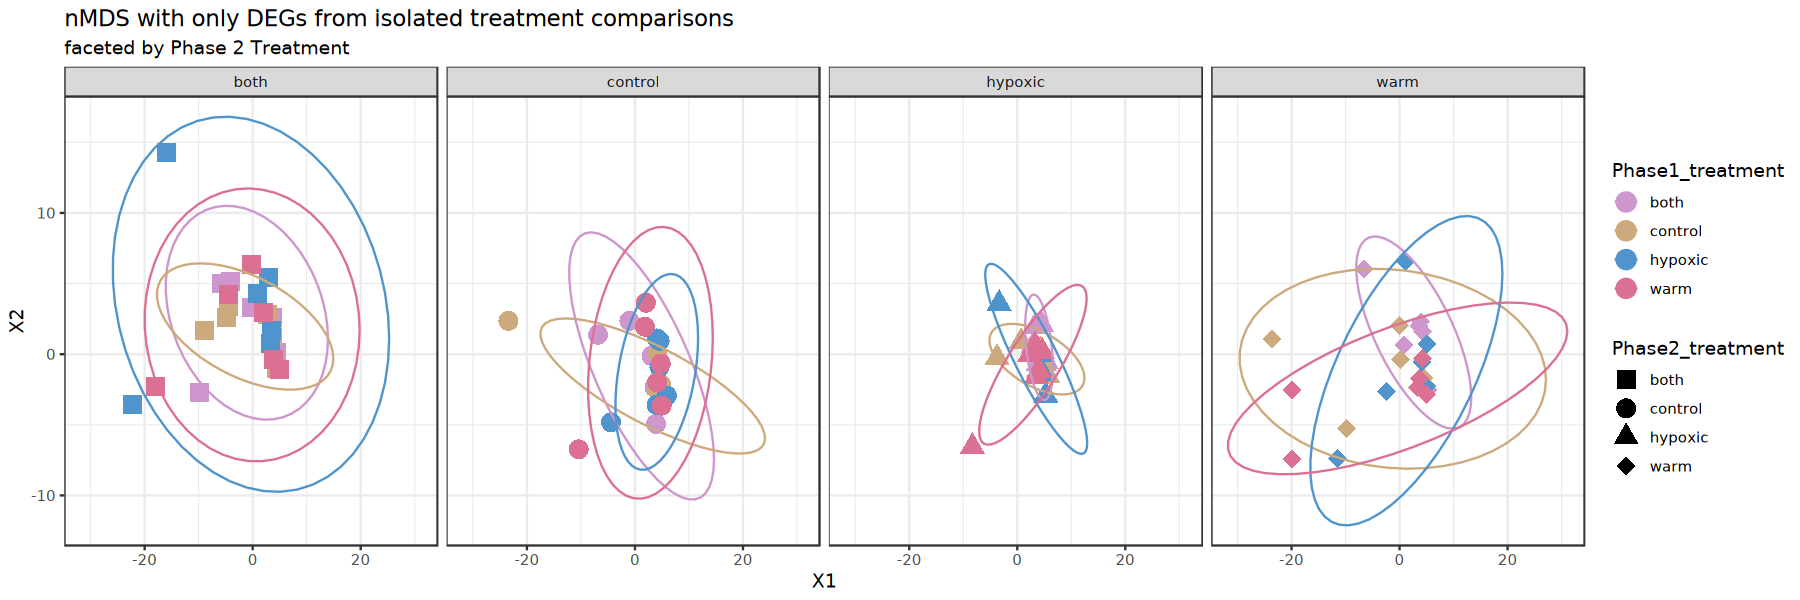

In [46]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase2_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 Treatment') + 
theme_bw()

nmds.plot

see less dispersion in phase 2 control and hypoxic (so ambient) samples compared to both and warm (so warm) samples 

this makes sense, as I've seen phase 2 temperature being a bigger driver for differential expression

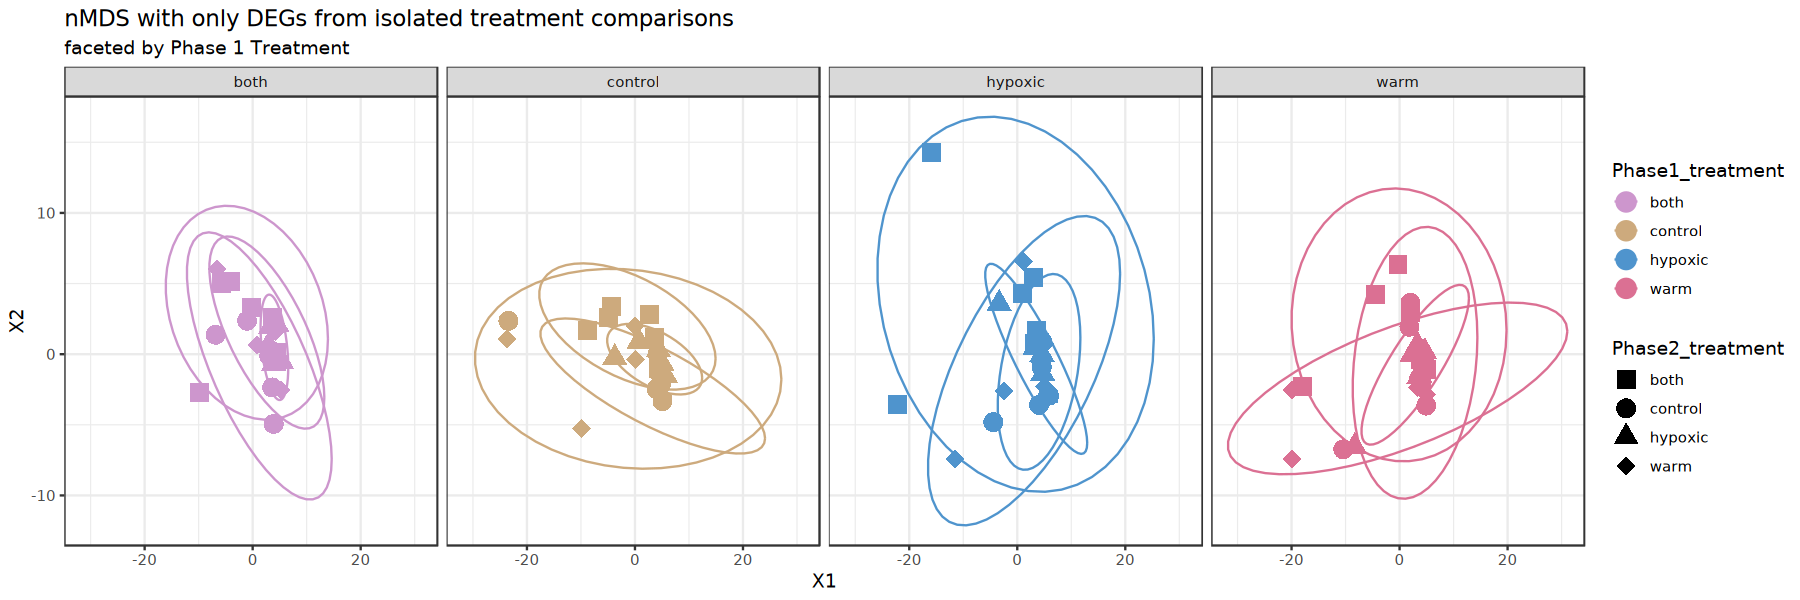

In [47]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase1_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 1 Treatment') + 
theme_bw()

nmds.plot

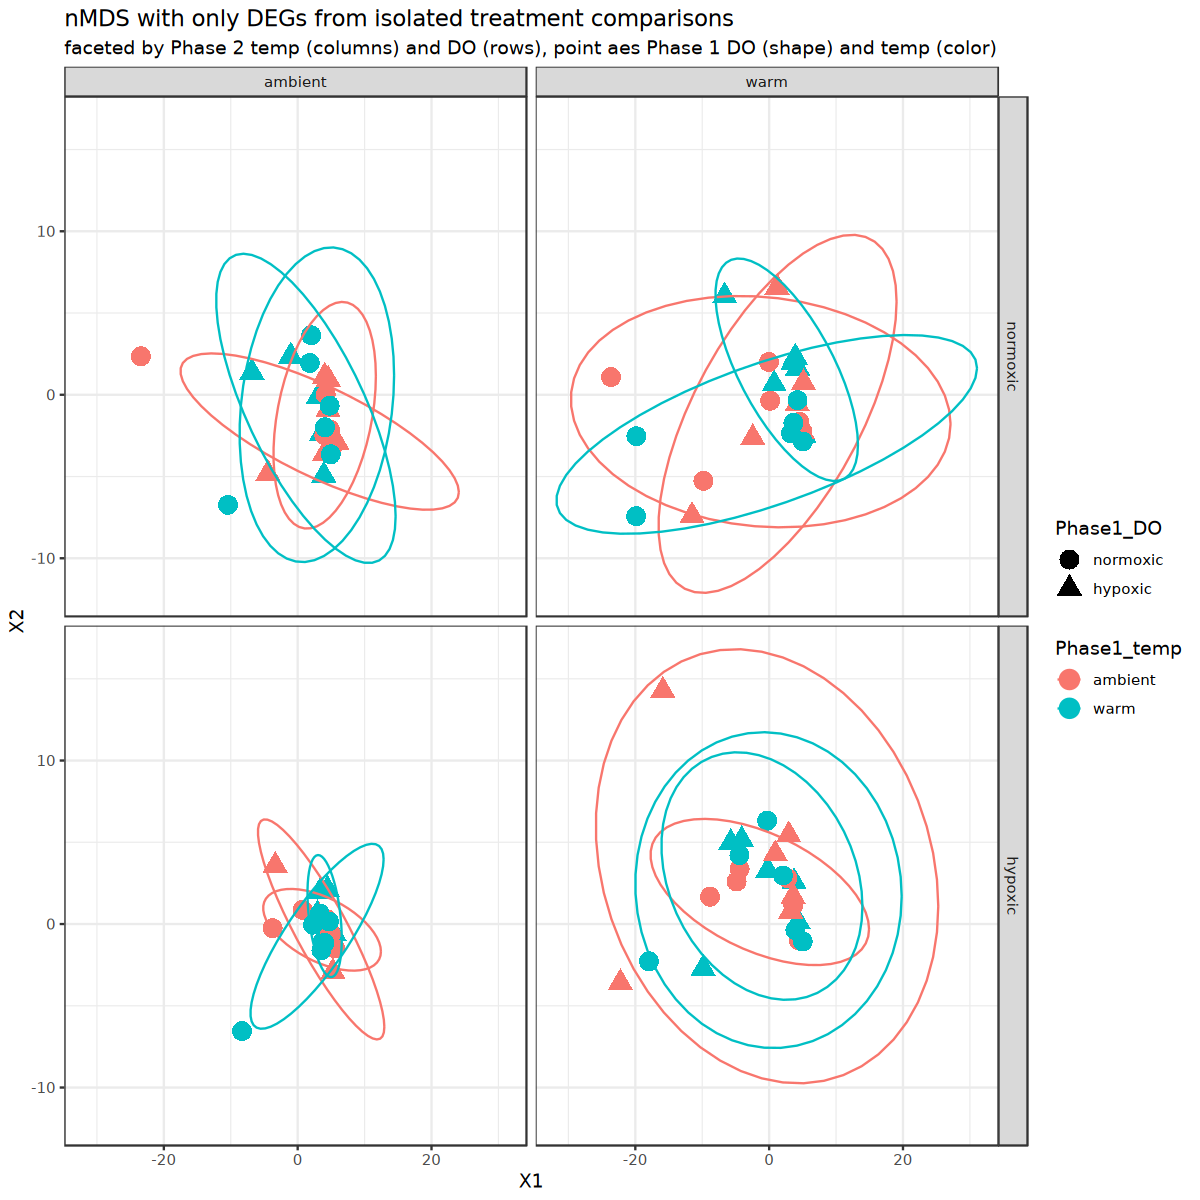

In [48]:
options(repr.plot.width = 10, repr.plot.height = 10)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
facet_grid(Phase2_DO~Phase2_temp) + 
stat_ellipse() + 
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 temp (columns) and DO (rows), point aes Phase 1 DO (shape) and temp (color)') + 
theme_bw()

nmds.plot

#### permanova for DEGs

In [49]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,66.09649,0.005232892,0.4968288,0.965
Phase1_DO,1,158.03661,0.012511838,1.1879171,0.260
Phase2_temp,1,612.46338,0.048489033,4.6037161,0.001
Phase2_DO,1,370.63484,0.029343346,2.7859585,0.023
Phase1_temp:Phase1_DO,1,84.56534,0.006695080,0.6356540,0.771
Phase1_temp:Phase2_temp,1,73.88016,0.005849130,0.5553365,0.886
Phase1_DO:Phase2_temp,1,63.09464,0.004995235,0.4742648,0.970
Phase1_temp:Phase2_DO,1,69.30171,0.005486651,0.5209216,0.926
Phase1_DO:Phase2_DO,1,140.79844,0.011147083,1.0583425,0.321


only significant effects from Phase2_temp and Phase2_DO - so most recent stressors

### nMDS of any DEG identified in all pairwise comparisons

In [16]:
# variance stabilizing transformation
vsd <- vst(dds.noOutliers) # from full DESeq function, without the 2 outlier samples
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111116054,7.692872,7.805746,7.871959,7.843091,7.548551,7.909124,7.947895,7.869635,7.840134,7.758281,⋯,7.767900,7.713596,7.900466,7.697844,7.834121,7.790482,7.708399,8.030152,7.657898,7.548551
LOC111126949,10.197580,9.653169,9.900281,9.718856,9.612738,9.545333,9.334530,9.803992,9.906070,9.592360,⋯,9.078093,9.779869,9.712370,10.082883,9.950378,9.563392,9.665533,9.644851,9.276775,9.929224
LOC111110729,8.354765,8.542687,8.351593,8.513945,8.518601,8.653091,8.816678,8.937210,8.568640,8.590933,⋯,8.714150,8.368627,8.514299,8.798284,8.635108,8.680883,8.780214,8.673395,8.746416,9.064164
LOC111112434,7.886383,7.697174,7.548551,7.687586,7.940109,7.989592,7.818256,8.186828,7.658920,7.879728,⋯,7.817069,7.548551,7.937395,7.806904,7.750644,7.548551,7.708399,7.990820,7.857315,7.548551
LOC111120752,9.363550,9.355360,9.509373,9.284512,9.198871,9.337765,9.699834,9.473806,8.989457,9.167603,⋯,9.549481,9.234610,9.599548,9.383933,9.510347,9.253648,9.345876,9.627837,9.412129,9.619853
LOC111128944,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,⋯,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551


get list of DEGs identified in the 'isolated' treatments (otherwise, there's just a million DEGs)

In [45]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/DEGs/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
names(geneList)

[1] "DEG_bb_cc" "DEG_bc_bb" "DEG_bc_cc" "DEG_bc_hc" "DEG_bc_wc" "DEG_bh_ch"
 [7] "DEG_bh_hh" "DEG_bw_cw" "DEG_bw_ww" "DEG_cb_bb" "DEG_cb_bc" "DEG_cb_cc"
[13] "DEG_cb_ch" "DEG_cb_cw" "DEG_ch_cc" "DEG_ch_hc" "DEG_cw_cc" "DEG_cw_ch"
[19] "DEG_cw_wc" "DEG_hb_bb" "DEG_hb_bh" "DEG_hb_cb" "DEG_hc_cc" "DEG_hc_hh"
[25] "DEG_hh_cc" "DEG_hh_ch" "DEG_wb_bb" "DEG_wb_bw" "DEG_wb_cb" "DEG_wc_cc"
[31] "DEG_wc_hc" "DEG_wc_ww" "DEG_wh_hw" "DEG_ww_cc" "DEG_ww_cw"

In [46]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 2263 total DEGs
head(all_degs)

[1] 2263

[1] "LOC111134671" "LOC111120923" "LOC111136853" "LOC111120760" "LOC111107221"
[6] "LOC111125595"

In [47]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 2263 total DEGs kept
head(degs_vsd) 

[1] 2263   94

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111105691,7.692872,7.845404,8.595408,8.101515,8.014009,8.149132,7.757585,8.212449,7.704598,7.805305,⋯,7.703729,7.713596,7.859081,7.548551,8.010013,7.736037,7.905257,8.416445,7.997691,7.548551
LOC111109550,8.131067,7.805746,8.743886,7.928364,7.708812,7.803846,8.159885,8.674840,7.704598,7.653485,⋯,7.985994,8.626921,7.714765,8.881685,10.092835,8.251878,9.960122,8.017421,8.058891,8.520289
LOC111102585,7.798315,8.004935,8.306724,8.475852,8.355585,7.548551,8.803914,7.948558,7.704598,7.758281,⋯,8.794420,7.817824,7.666114,8.234621,7.898017,7.548551,10.227302,8.077917,7.875967,9.296881
LOC111129522,7.548551,8.120664,7.887674,8.066193,8.144263,7.926626,8.494087,7.548551,7.860191,7.782985,⋯,8.094194,7.548551,9.987741,7.697844,9.097456,7.872833,8.173305,7.898706,7.857315,8.129922
LOC111119645,11.013693,8.101502,11.484225,8.037954,7.548551,7.776953,7.774301,7.548551,7.704598,7.696918,⋯,9.367806,7.951734,7.811141,8.938418,8.740486,7.854358,7.825135,7.976880,8.123486,8.262219
LOC111129878,7.650623,7.548551,7.871959,7.952738,7.661902,7.776953,7.919830,7.548551,7.548551,7.653485,⋯,7.548551,7.548551,7.880431,7.806904,7.795962,7.656847,7.661610,7.931939,7.816075,7.548551


In [48]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,46.43361,45.73539,43.84645,49.73550,44.43556,47.39553,43.74362,46.22663,41.88886,⋯,57.89188,42.65465,39.22486,39.07451,38.70156,41.73571,59.67276,42.59358,41.49088,59.86365
B1_W5_O50,46.43361,0.00000,50.88725,35.16716,40.25746,37.80542,36.85094,39.82587,39.26073,38.94531,⋯,50.92336,40.06429,39.28590,44.69943,43.99756,41.04530,53.09433,40.34483,38.75099,50.03105
B2_B5_O51,45.73539,50.88725,0.00000,50.60368,50.77186,51.57691,49.44982,52.85483,54.79573,51.71212,⋯,52.67049,52.82034,51.48311,42.86659,48.04415,52.55684,58.24607,51.88533,48.80898,53.92939
B2_C4_O40,43.84645,35.16716,50.60368,0.00000,42.74597,33.38867,39.20402,38.13177,39.36770,37.22117,⋯,53.58619,37.38804,38.27075,43.05805,41.64574,40.47929,57.77789,37.40804,33.11933,53.52733
B3_B4_O41,49.73550,40.25746,50.77186,42.74597,0.00000,45.87647,43.81807,46.81046,39.69463,47.11637,⋯,42.79811,47.87468,46.67330,47.61091,49.46200,48.35379,45.50210,45.57722,46.29409,42.70204
B3_C3_O30,44.43556,37.80542,51.57691,33.38867,45.87647,0.00000,41.11701,40.36882,41.73098,37.71411,⋯,56.16122,38.34243,38.44486,44.86054,42.96716,39.30128,57.66326,39.16953,37.81118,54.84643


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>
B1_B1_O01,8.434536,12.217624,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0666333
B1_W5_O50,-3.341411,-8.427508,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,1.0057329
B2_B5_O51,-7.695686,20.238490,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0584922
B2_C4_O40,3.140779,-7.068260,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1493541
B3_B4_O41,-16.873005,-7.050391,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8648335
B3_C3_O30,5.335760,-7.838027,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8506698


Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


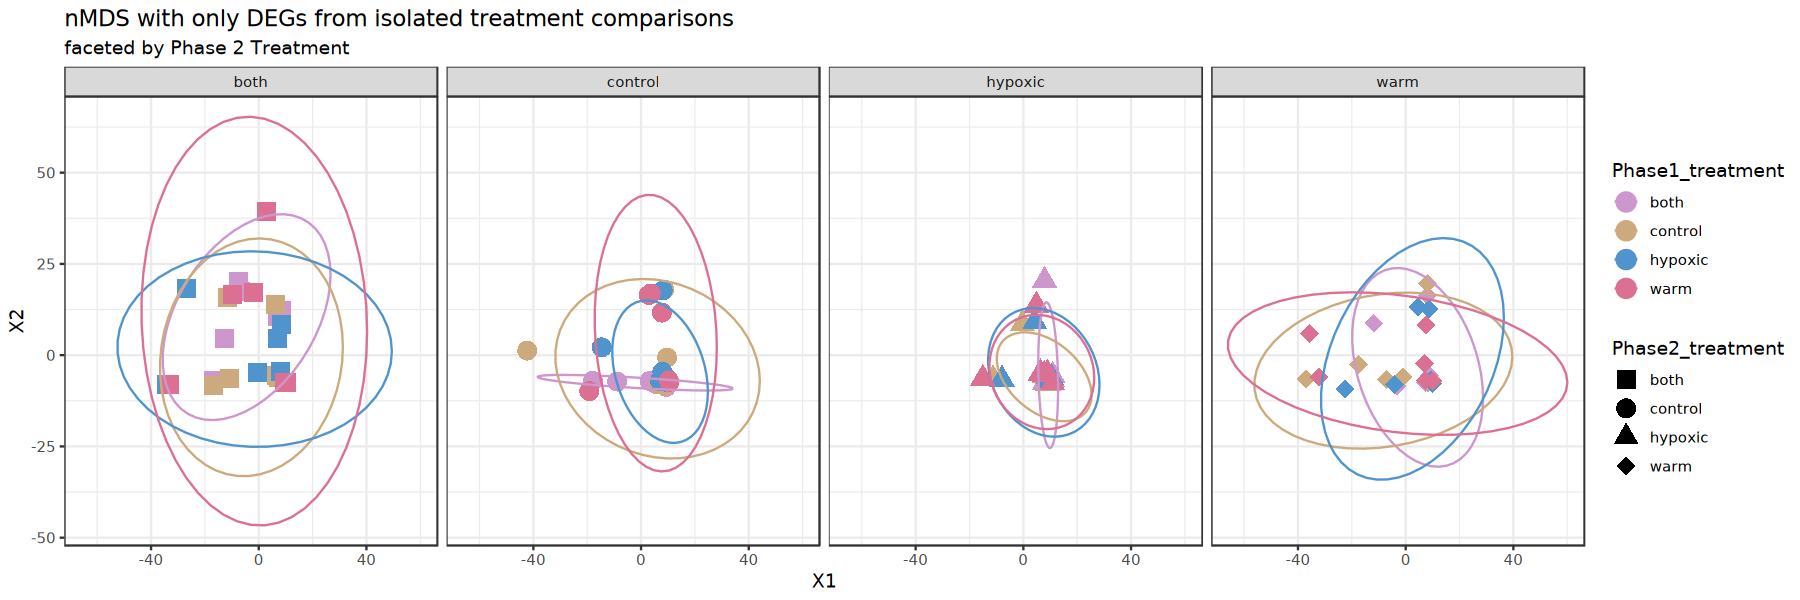

In [49]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase2_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 Treatment') + 
theme_bw()

nmds.plot

BC samples (purple circles) - super tight clustering; same with BH samples (purple triangles)

Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


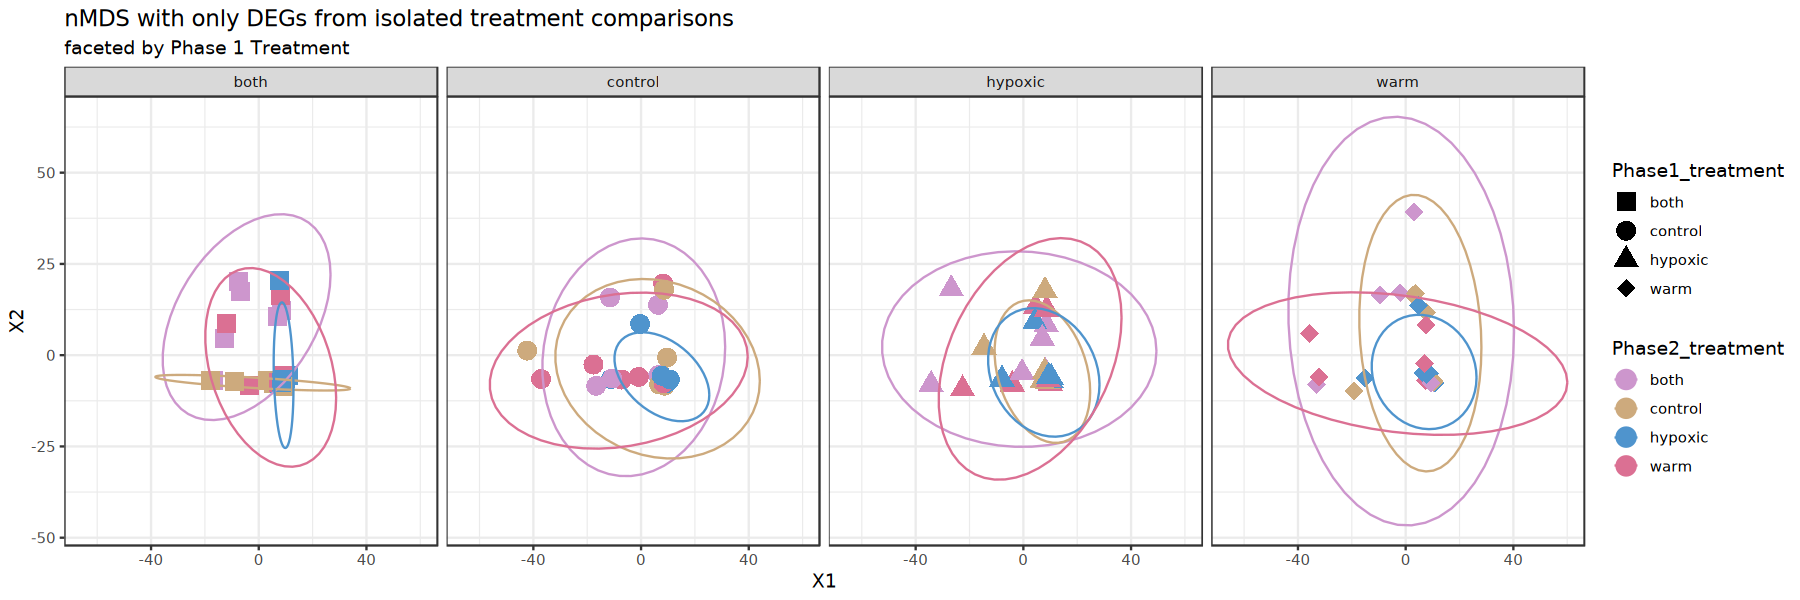

In [58]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, shape = Phase1_treatment, col = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase1_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 1 Treatment') + 
theme_bw()

nmds.plot

*coloring and shapes are reversed from above*

- phase 2 hypoxic (blue) seems to have a less dispersed GE profile - tighter circling in all grids
- phase 2 both has more dispersed profile in all grids, less specific response/depends on the early stressor?